In [2]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly, find_peaks
import neurokit2 as nk
import rsp.data_processing.signal_processing as signal_processing
from rsp.plotting import Rsp_Kit

import importlib
importlib.reload(signal_processing)
importlib.reload(Rsp_Kit)

<module 'rsp.plotting.Rsp_Kit' from 'C:\\Users\\sjs93\\OneDrive\\Documents\\respiratory_pilot\\src\\rsp\\plotting\\Rsp_Kit.py'>

In [3]:
pd.set_option('display.max_colwidth', 0)  # 0 means unlimited in newer pandas versions

# Show all rows
pd.set_option("display.max_rows", None)

# Show all columns
pd.set_option("display.max_columns", None)

# Don’t truncate column contents
pd.set_option("display.max_colwidth", None)

# Expand the display to the full width of the screen
pd.set_option("display.width", 0)


In [4]:
# RESP FILE PATHS
RI1_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5"
RI2_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_6_p5_3_nRB3_20250621_131158_merged.h5"
BLRI_s3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s3_6_p5_3_nRB3_20250621_123634_merged.h5"
BLRI_s4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_7_p5_2_nRB3_20250621_144806_merged.h5"
RI_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5"
RI2_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5"
RI1_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_3_p5_3_nRB3_20250622_104059_merged (1).h5"
RI2_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_3_p5_3_nRB3_20250622_110216_merged.h5"

# BORIS CSVs (no comma at the end or it makes a tuple)
RI1_3_6_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s3_6_p5_3_nRB3_HEEPS.csv")
RI2_3_6_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_6_p_5_3_nRB3_2025062.csv")
RI1_4_7_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_7_p5_2_nRB3_HEEPS.csv")
RI2_4_7_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_7_p5_2_nRB3_HEEPS.csv")
RI1_2_3_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_3_p5_3_nRB3_20250622_104059.1.csv")
RI2_2_3_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_3_p5_3_nRB3_20250622_1102116.1.csv")

In [11]:
RI2_3_6_boris

,Observation id,Observation date,Description,Observation type,Source,Time offset (s),Coding duration,Media duration (s),FPS (frame/s),Subject,Observation duration by subject by observation,Behavior,Behavioral category,Behavior type,Start (s),Stop (s),Duration (s),Media file name,Image index start,Image index stop,Image file path start,Image file path stop,Comment start,Comment stop
12,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,0.0,603.9,608.733,30.0,social_agent,146.335,facial sniffing,Not defined,STATE,25.600,26.100,0.500,E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,768,783.0,NaN,NaN,NaN,NaN
13,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,0.0,603.9,608.733,30.0,social_agent,146.335,body sniffing,Not defined,STATE,26.167,26.467,0.300,E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,785,794.0,NaN,NaN,NaN,NaN
14,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,0.0,603.9,608.733,30.0,social_agent,146.335,anogenital sniffing,Not defined,STATE,26.600,26.667,0.067,E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,798,800.0,NaN,NaN,NaN,NaN
15,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,0.0,603.9,608.733,30.0,social_agent,146.335,Posturing,Not defined,STATE,32.567,35.900,3.333,E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,977,1077.0,NaN,NaN,NaN,NaN
23,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,0.0,603.9,608.733,30.0,social_agent,146.335,facial sniffing,Not defined,STATE,68.767,69.600,0.833,E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,2063,2088.0,NaN,NaN,NaN,NaN
25,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,0.0,603.9,608.733,30.0,social_agent,146.335,fighting,Not defined,STATE,70.833,80.533,9.700,E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,2125,2416.0,NaN,NaN,NaN,NaN
26,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,0.0,603.9,608.733,30.0,social_agent,146.335,chasing,Not defined,STATE,80.533,80.899,0.366,E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,2416,NaN,NaN,NaN,NaN,NaN
27,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,0.0,603.9,608.733,30.0,social_agent,146.335,fighting,Not defined,STATE,80.900,81.567,0.667,E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,2427,2447.0,NaN,NaN,NaN,NaN
28,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,0.0,603.9,608.733,30.0,social_agent,146.335,chasing,Not defined,STATE,81.567,82.500,0.933,E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,2447,2475.0,NaN,NaN,NaN,NaN
30,RI

### Filtering out social_agent so only subject behaviors plotted

In [5]:
# taking out all rows with subject=social_agent
RI2_3_6_boris = RI2_3_6_boris[RI2_3_6_boris['Subject'] != 'subject']

In [6]:
RI2_3_6_boris.head()

,Observation id,Observation date,Description,Observation type,Source,Time offset (s),Coding duration,Media duration (s),FPS (frame/s),Subject,Observation duration by subject by observation,Behavior,Behavioral category,Behavior type,Start (s),Stop (s),Duration (s),Media file name,Image index start,Image index stop,Image file path start,Image file path stop,Comment start,Comment stop
12,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,0.0,603.9,608.733,30.0,social_agent,146.335,facial sniffing,Not defined,STATE,25.600,26.100,0.500,E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,768,783.0,NaN,NaN,NaN,NaN
13,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,0.0,603.9,608.733,30.0,social_agent,146.335,body sniffing,Not defined,STATE,26.167,26.467,0.300,E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,785,794.0,NaN,NaN,NaN,NaN
14,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,0.0,603.9,608.733,30.0,social_agent,146.335,anogenital sniffing,Not defined,STATE,26.600,26.667,0.067,E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,798,800.0,NaN,NaN,NaN,NaN
15,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,0.0,603.9,608.733,30.0,social_agent,146.335,Posturing,Not defined,STATE,32.567,35.900,3.333,E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,977,1077.0,NaN,NaN,NaN,NaN
23,RI2_s3_6_p_5_3_nRB3,2025-06-29 12:05:18.871,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,0.0,603.9,608.733,30.0,social_agent,146.335,facial sniffing,Not defined,STATE,68.767,69.600,0.833,E:/Aim1/AIM1/Day1_new/RI2_s3_6_p_5_3_nRB3_20250621_131158.rec/RI2_s3_6_p_5_3_nRB3_20250621_131158.1.mp4,2063,2088.0,NaN,NaN,NaN,NaN


### Function to quickly get read and filter resp data and create Rsp_Kit object with behavior

In [7]:
def get_kit(h5_file, target_rate=100, behavior_data=None):
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            ekg_meta = dict(f['ekg_metadata'].attrs)
    except Exception as e:
        return {"file": os.path.basename(h5_file), "error": str(e)}

    try:
        duration_sec = ekg_meta['duration_sec']
        fs = len(resp) / duration_sec
    except KeyError:
        return {"file": os.path.basename(h5_file), "error": "Missing 'duration_sec' metadata"}

    # Step 1: Pre-downsampling apply low-pass filter
    cutoff_hz = target_rate / 2
    nyquist = fs / 2
    norm_cutoff = cutoff_hz / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Step 2: Downsample
    downsample_factor = int(fs // target_rate)
    downsampled_resp = resample_poly(filtered_resp, up=1, down=downsample_factor)
    duration_downsampled = len(downsampled_resp) / target_rate

    # Step 3: Apply neurokit2 Butterworth bandpass filter after downsampling
    rsp_cleaned = nk.signal_filter(
        downsampled_resp,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    return Rsp_Kit.Rsp_Kit(rsp_cleaned, fs=target_rate, n_samples=len(rsp_cleaned), behavior_data=behavior_data)


In [8]:
RI2_focal_subj_3_6_kit = get_kit(RI2_3_6_h5_path, target_rate=100, behavior_data=RI2_3_6_boris)

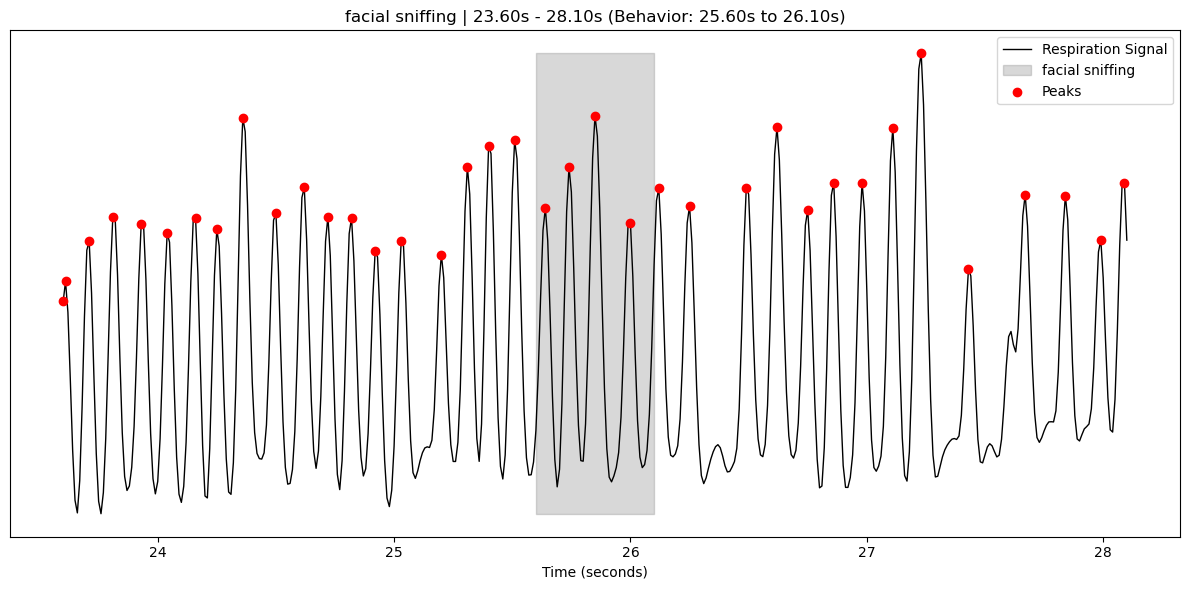

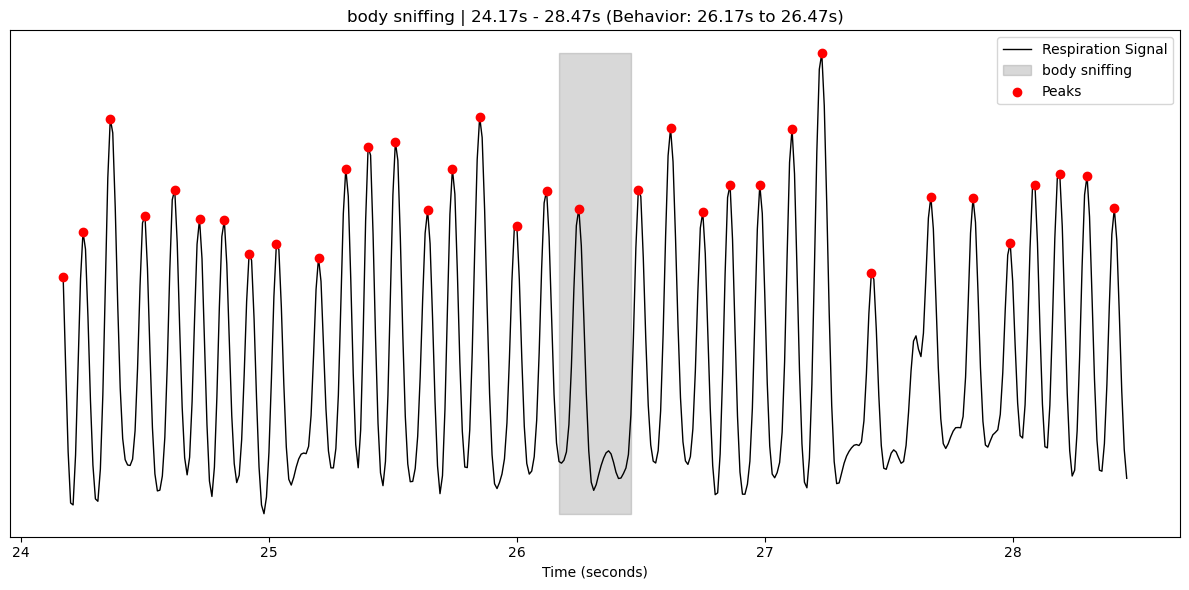

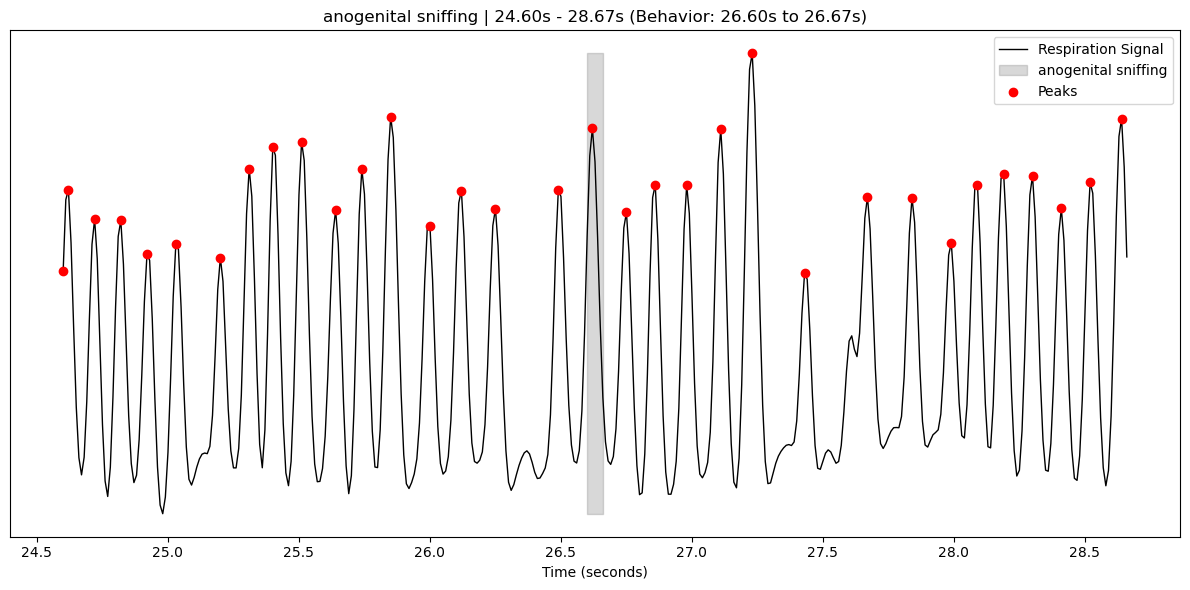

Skipping behavior 'Posturing' (excluded).


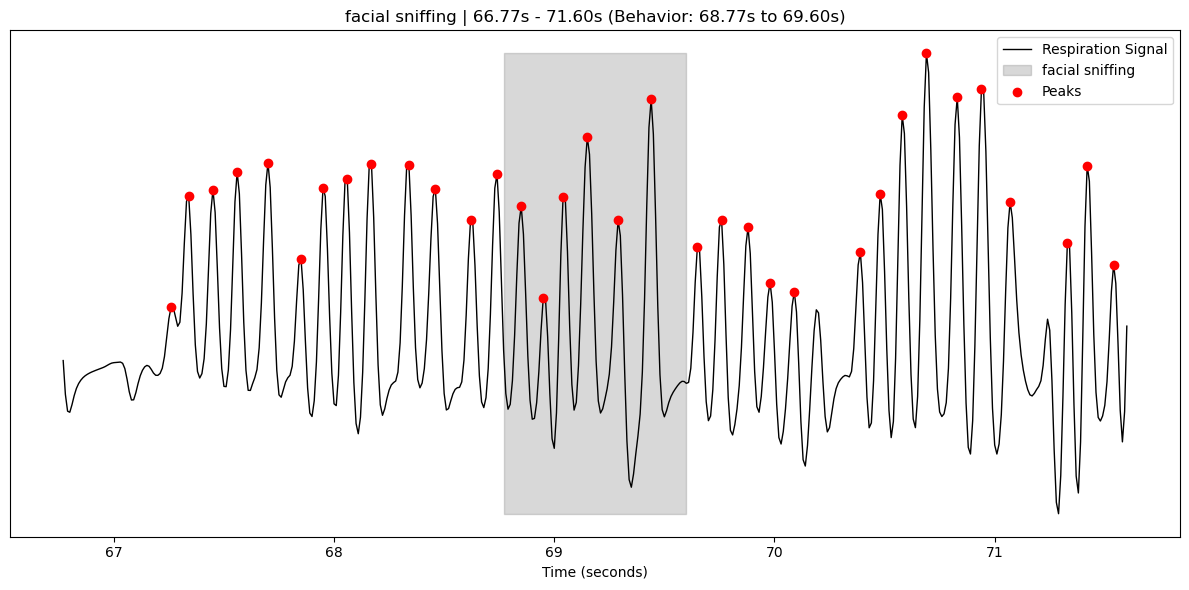

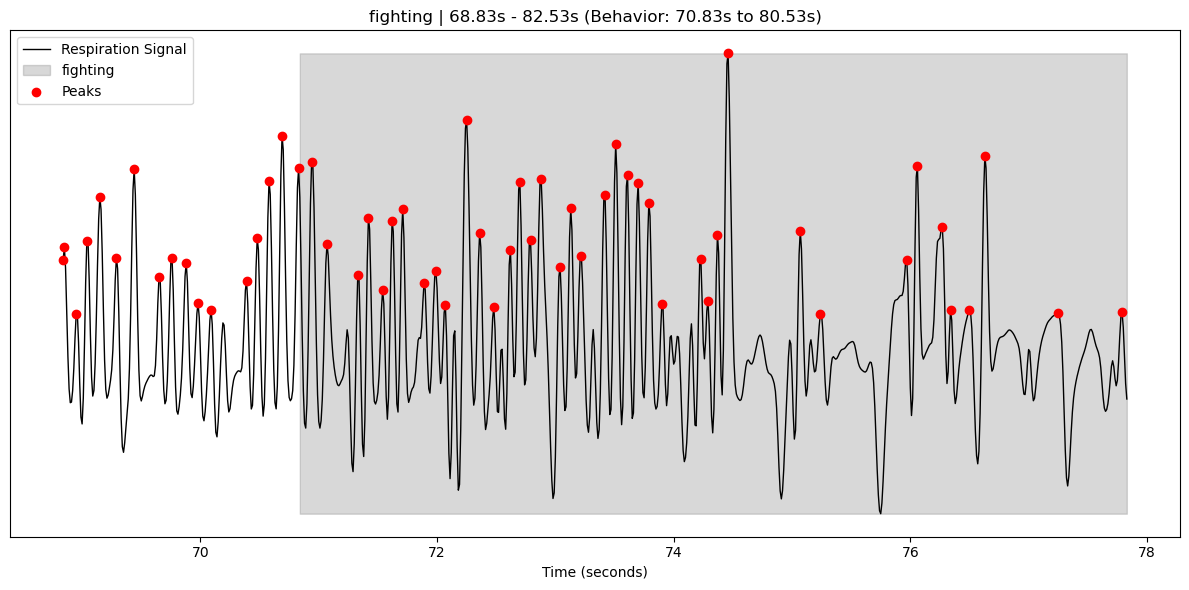

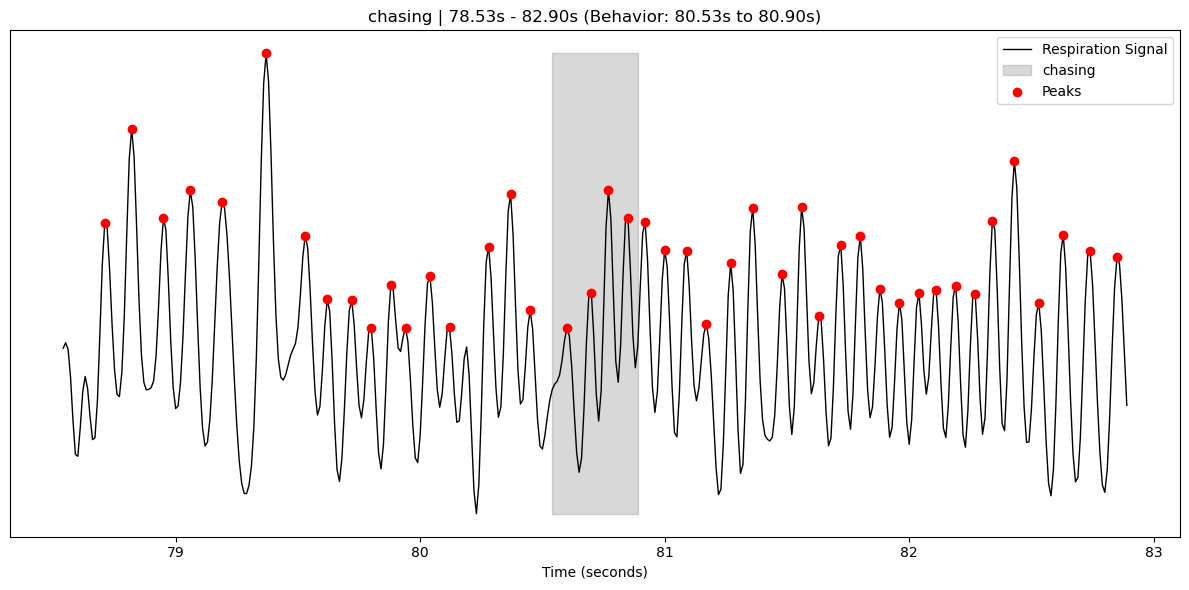

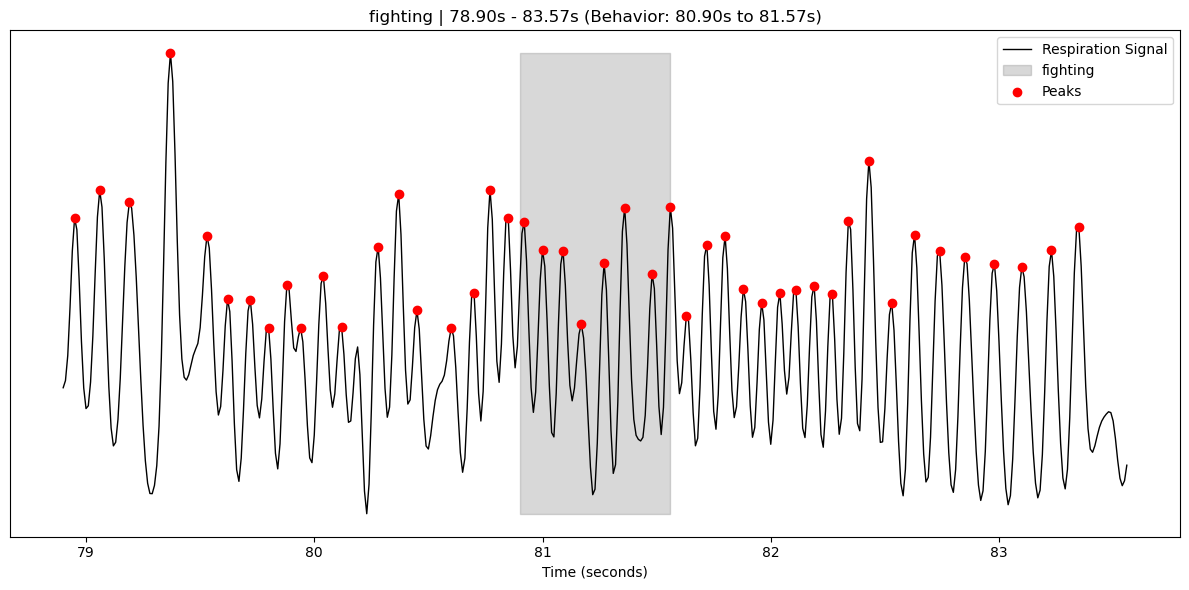

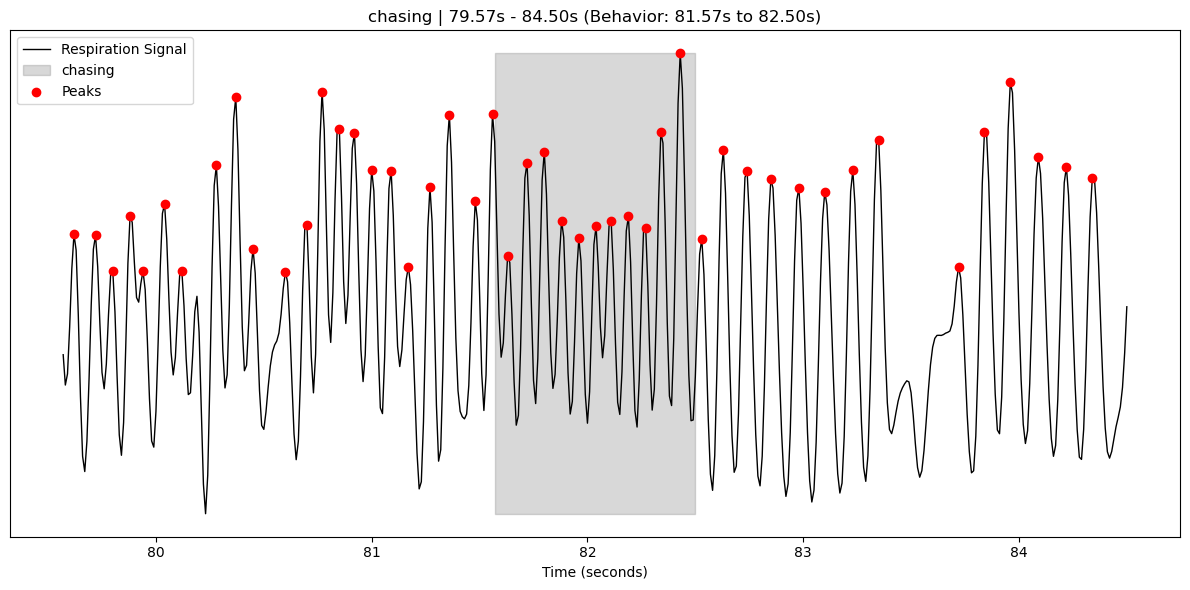

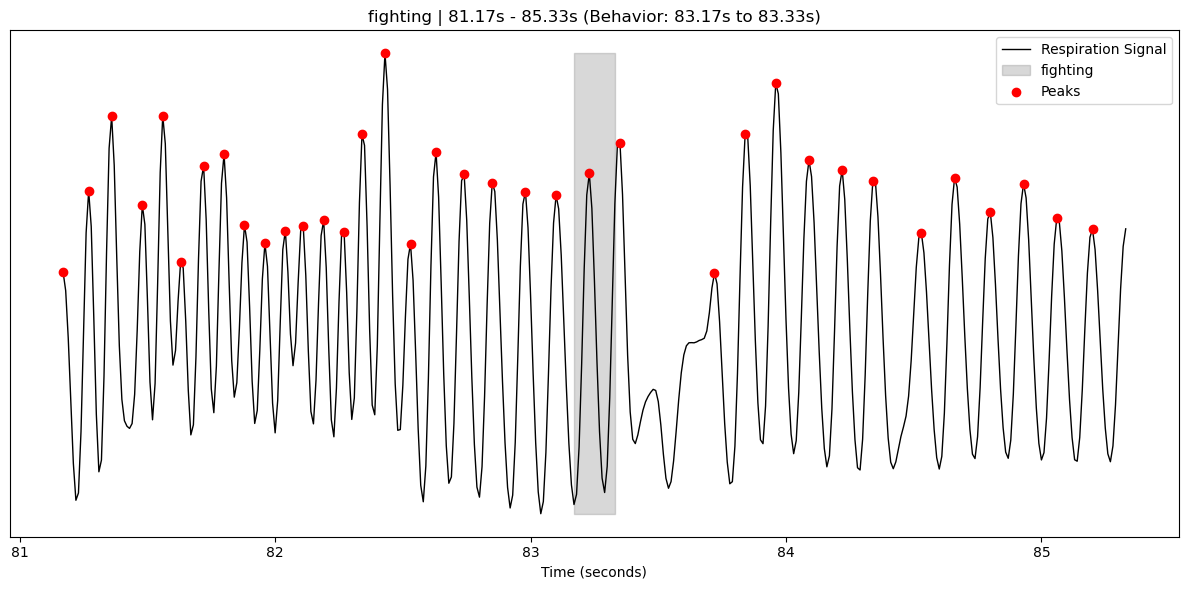

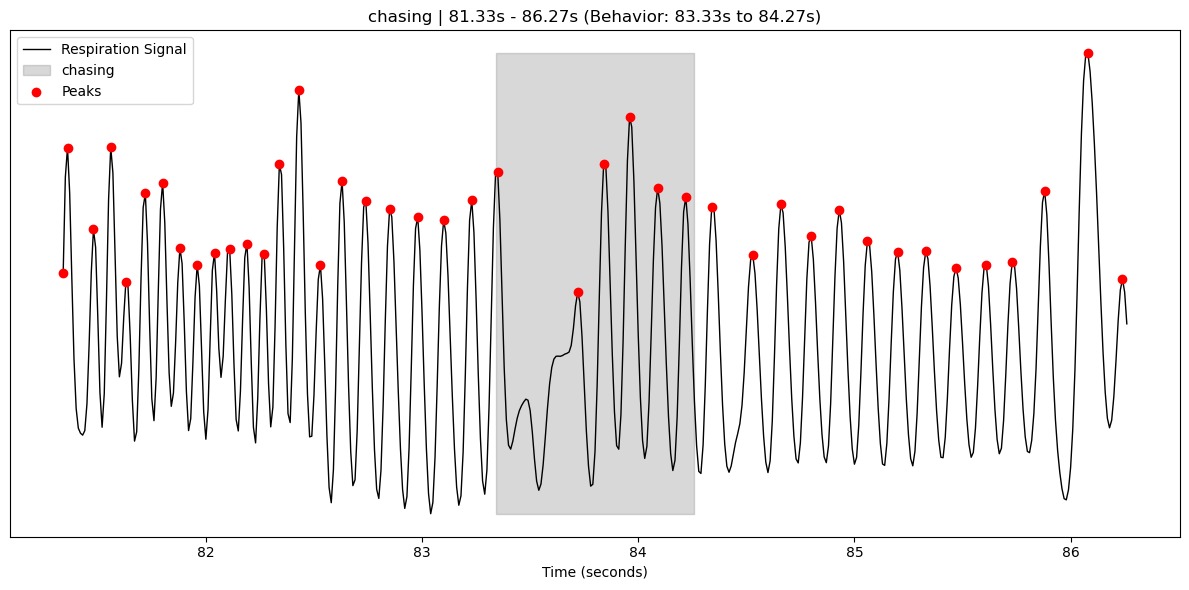

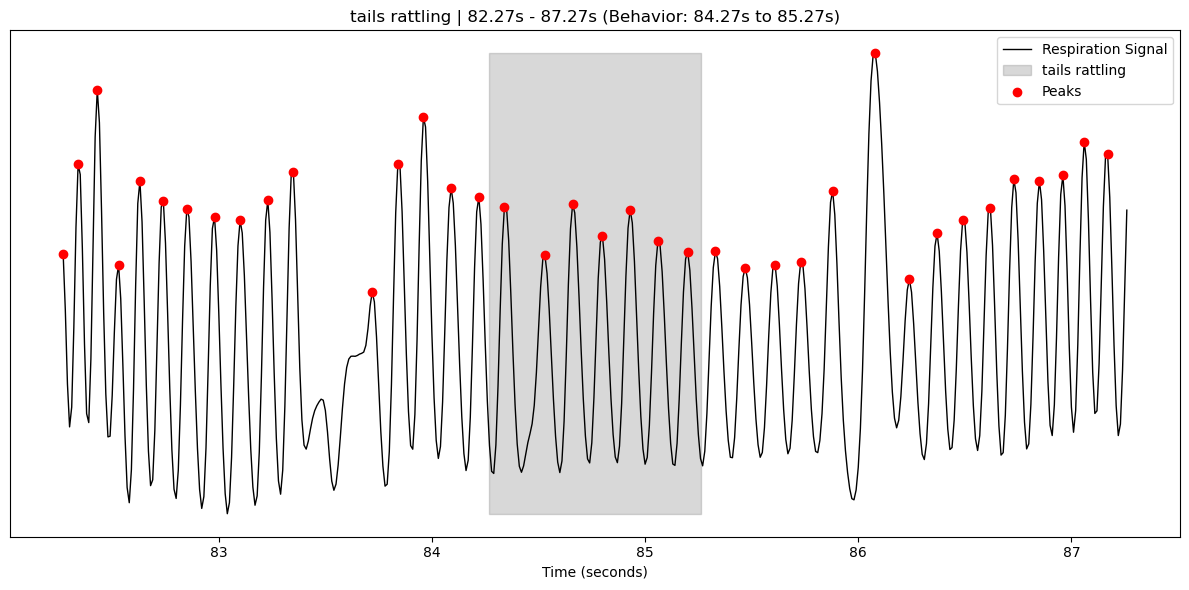

Skipping behavior 'Posturing' (excluded).


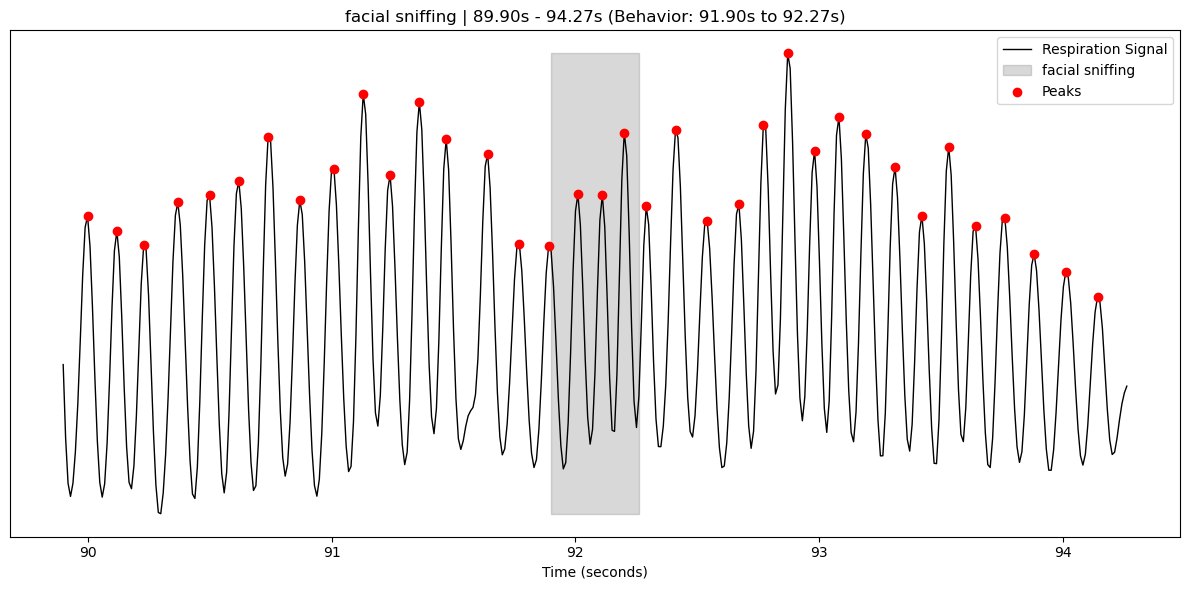

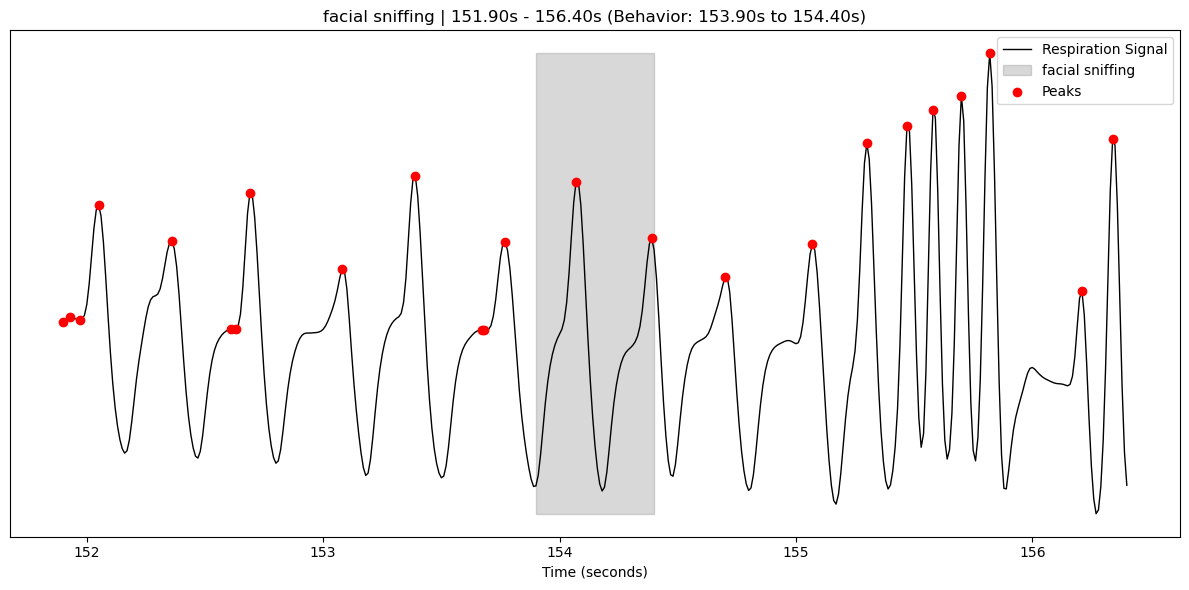

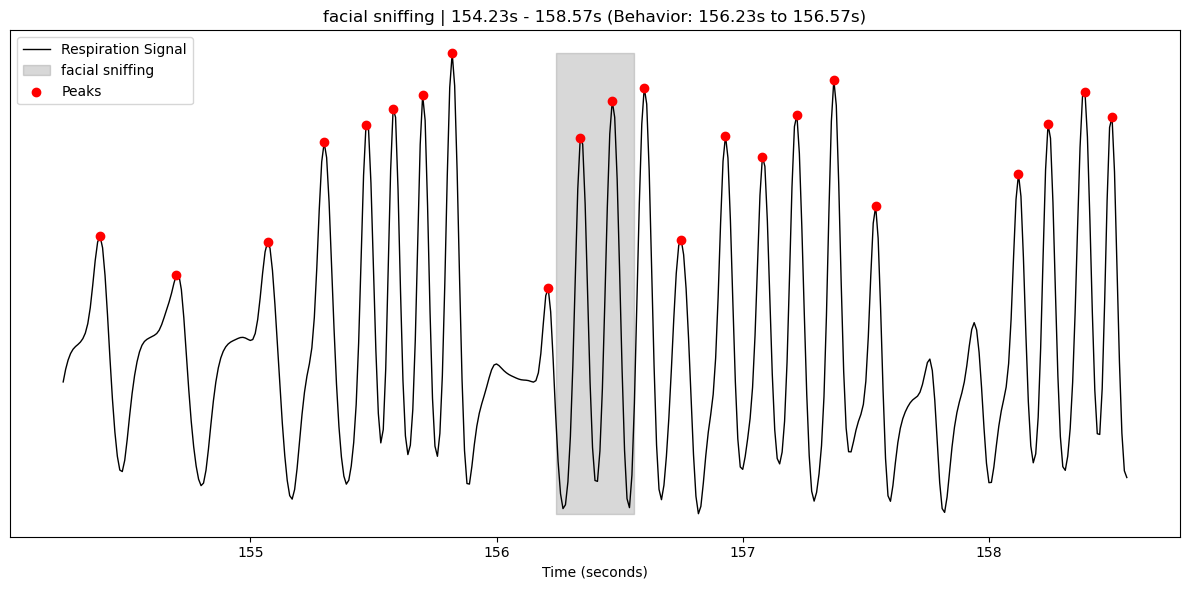

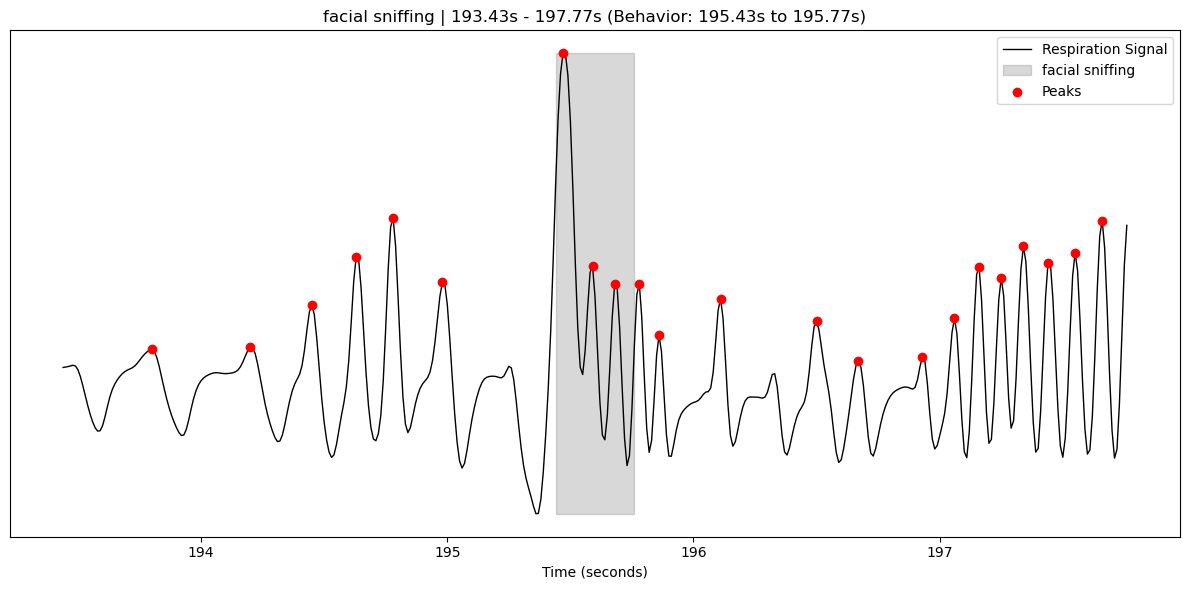

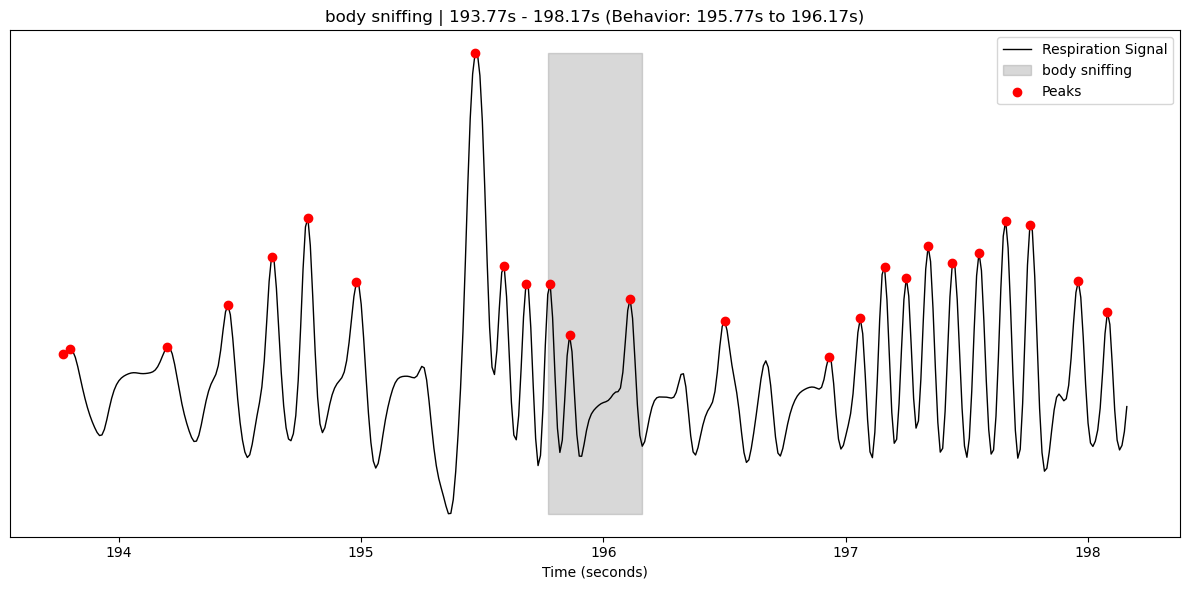

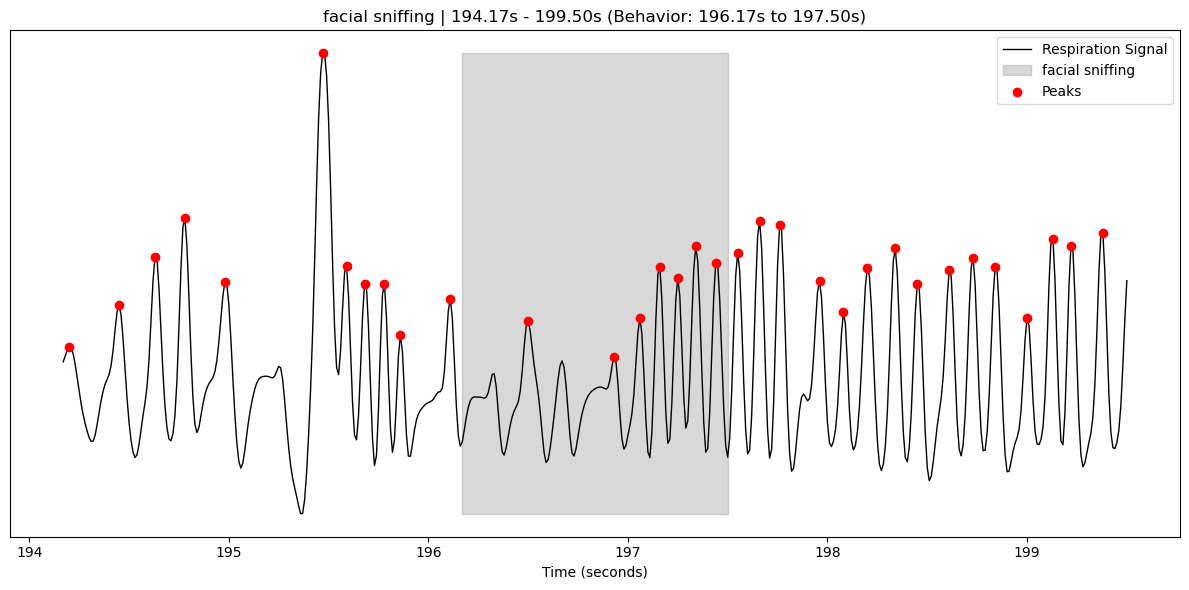

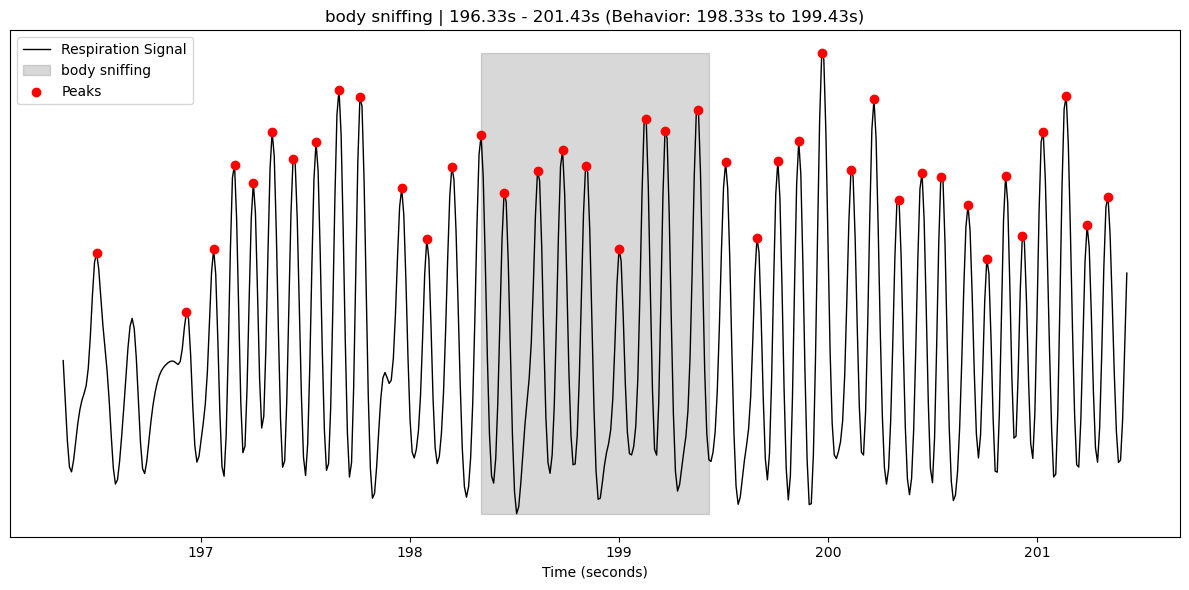

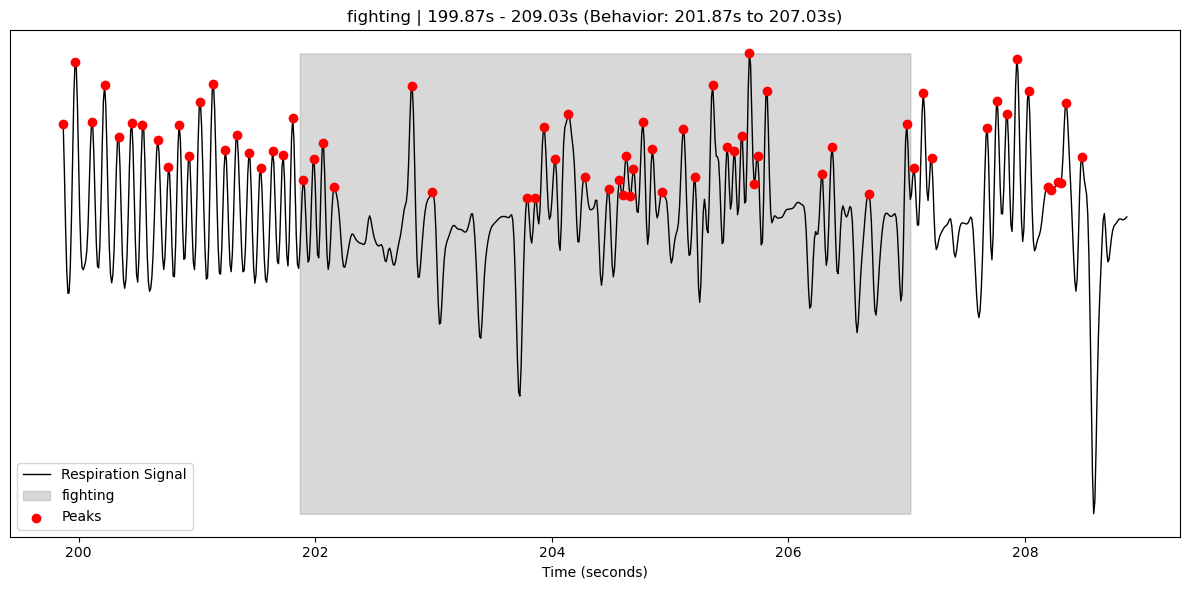

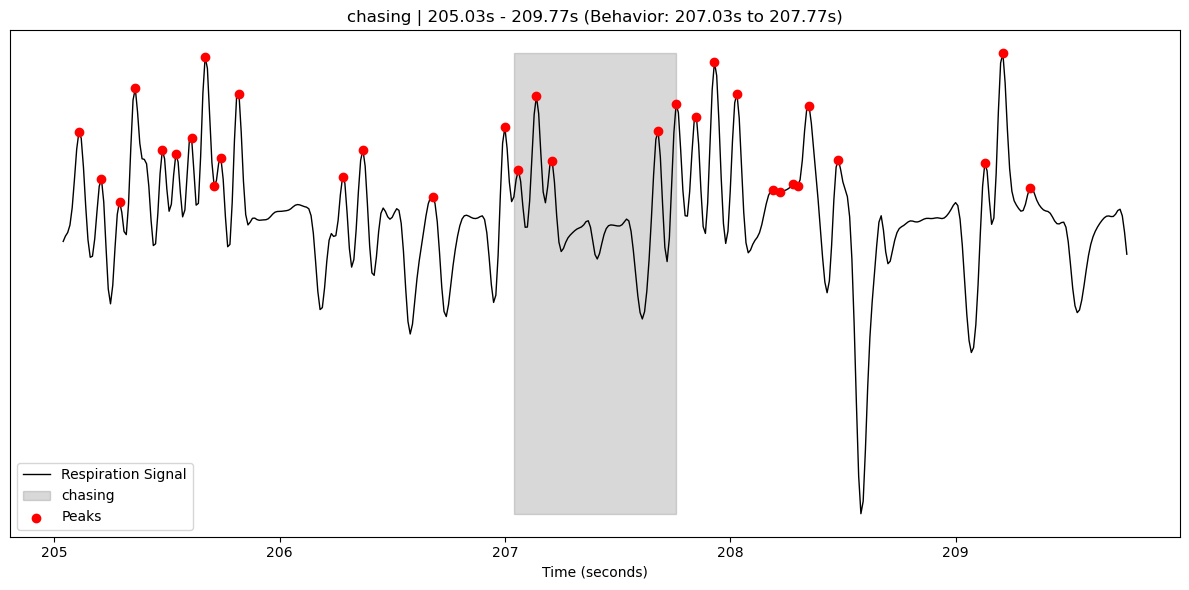

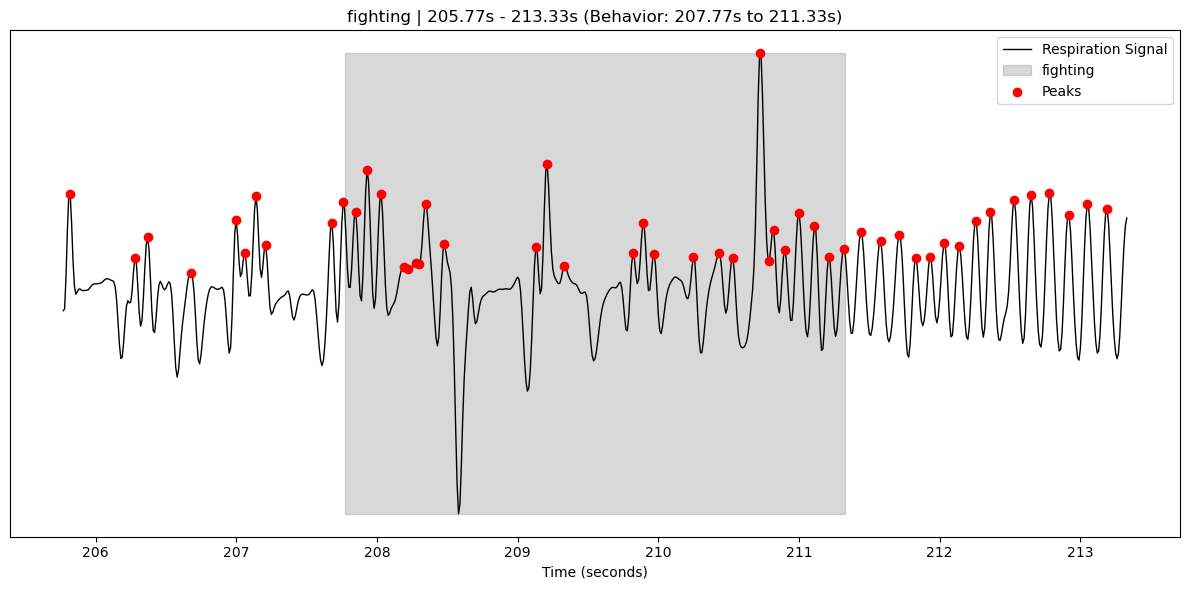

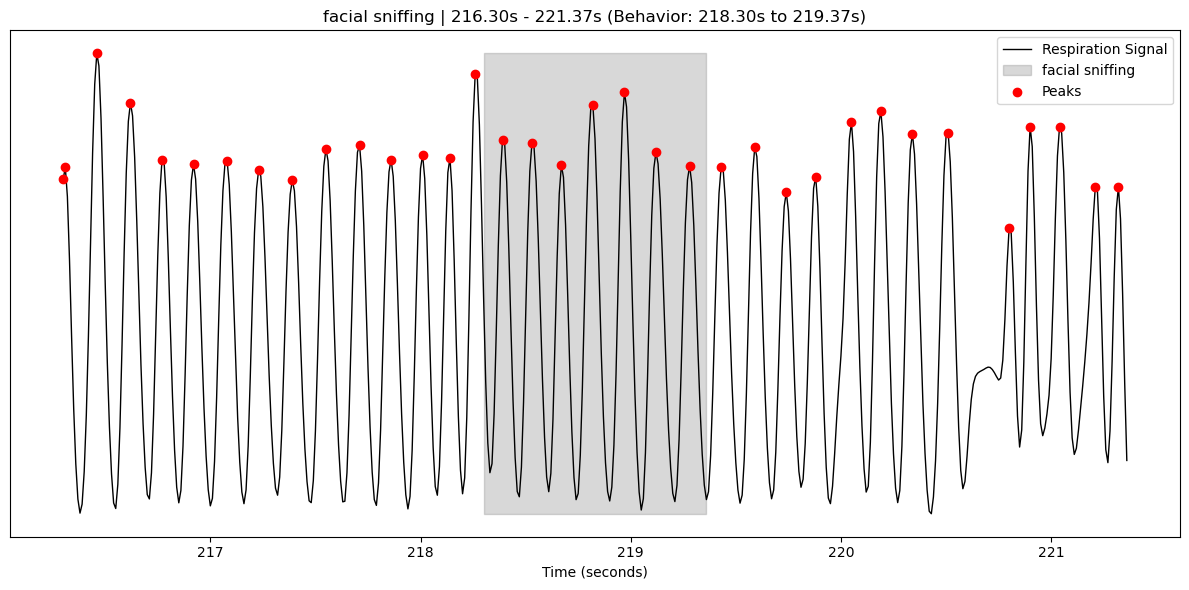

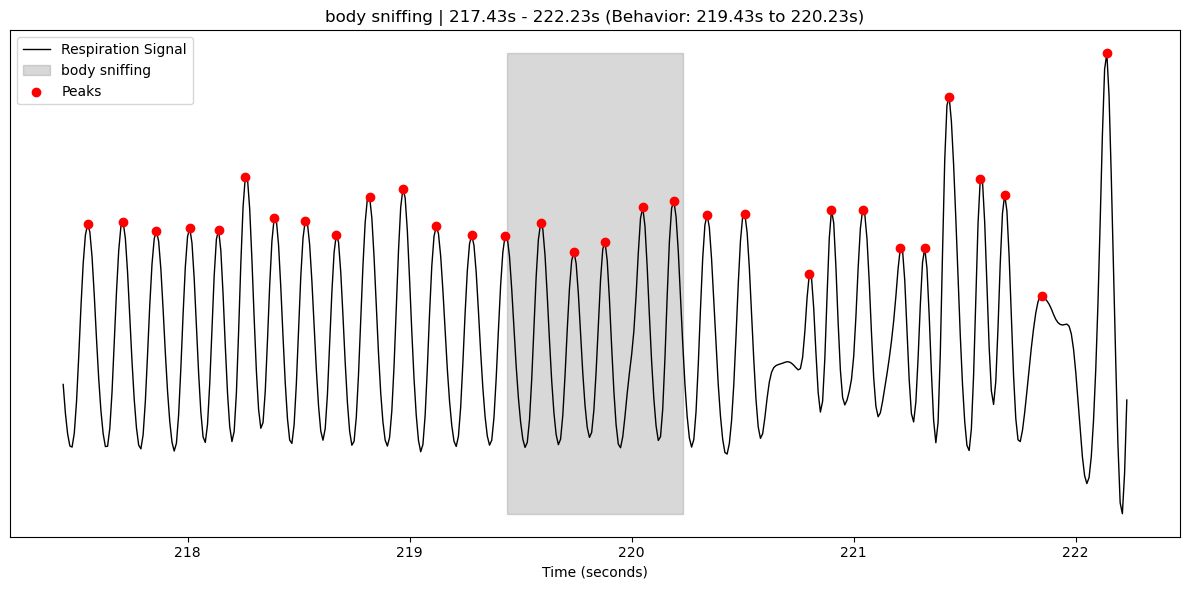

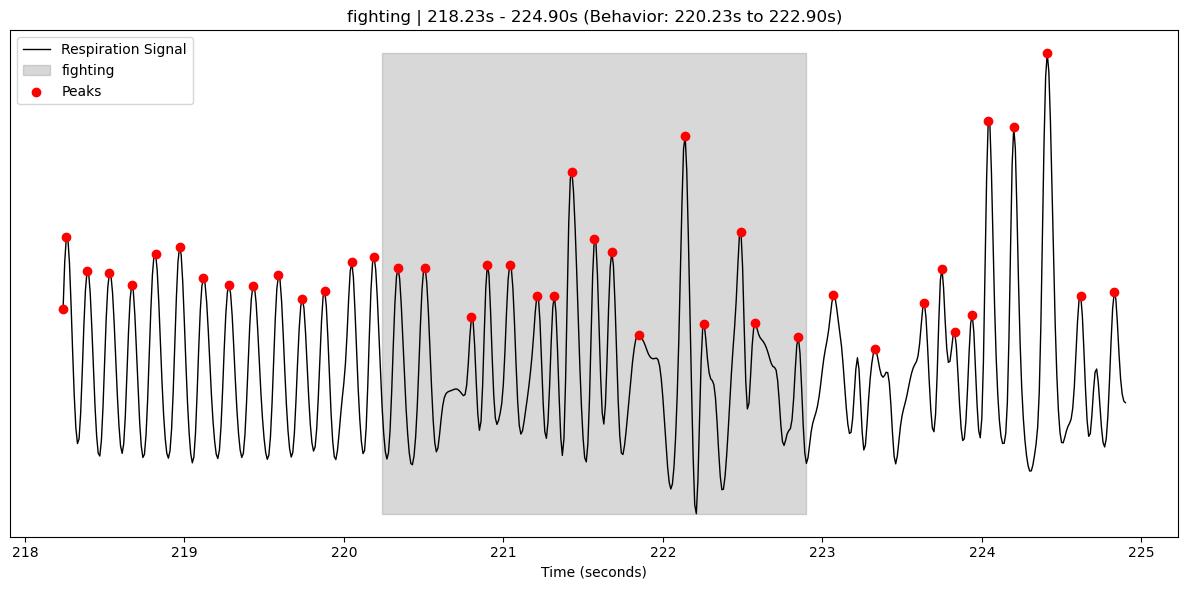

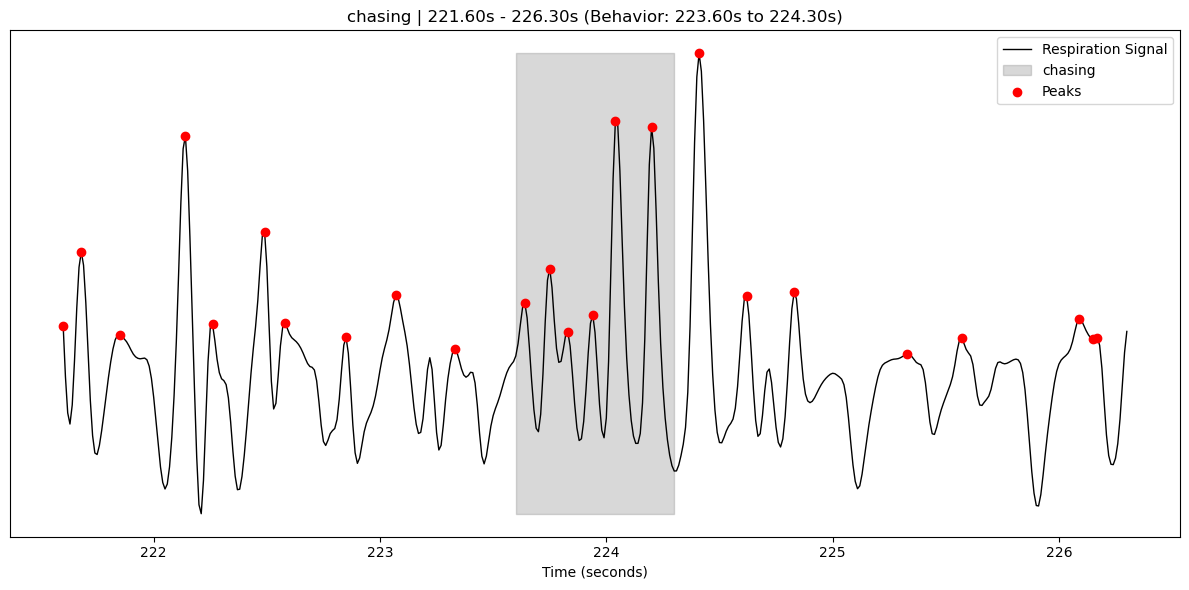

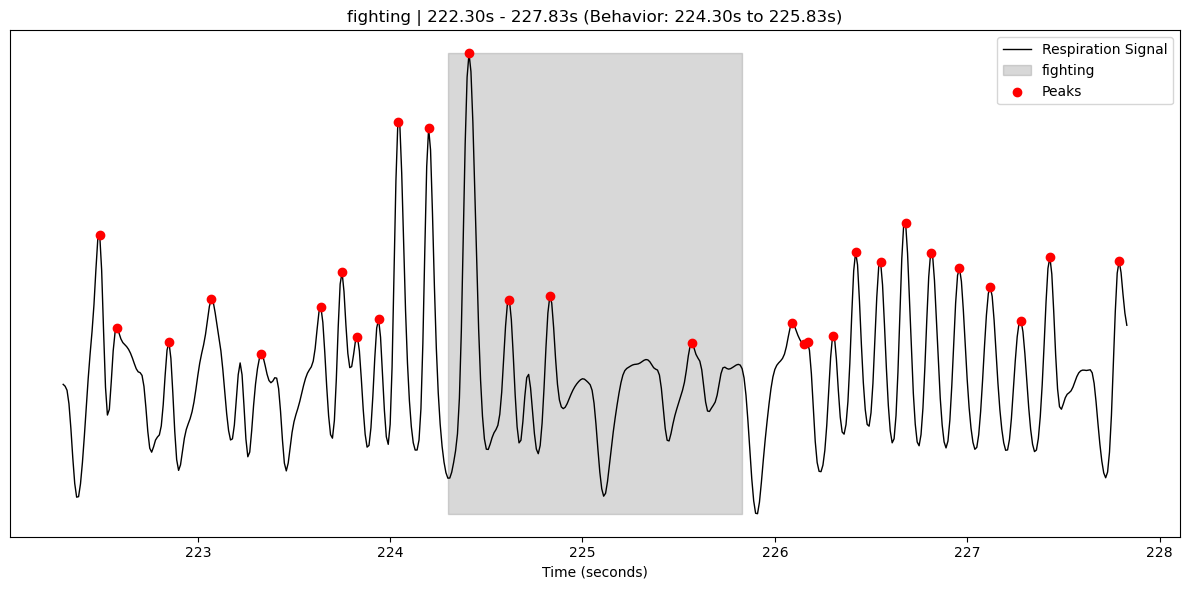

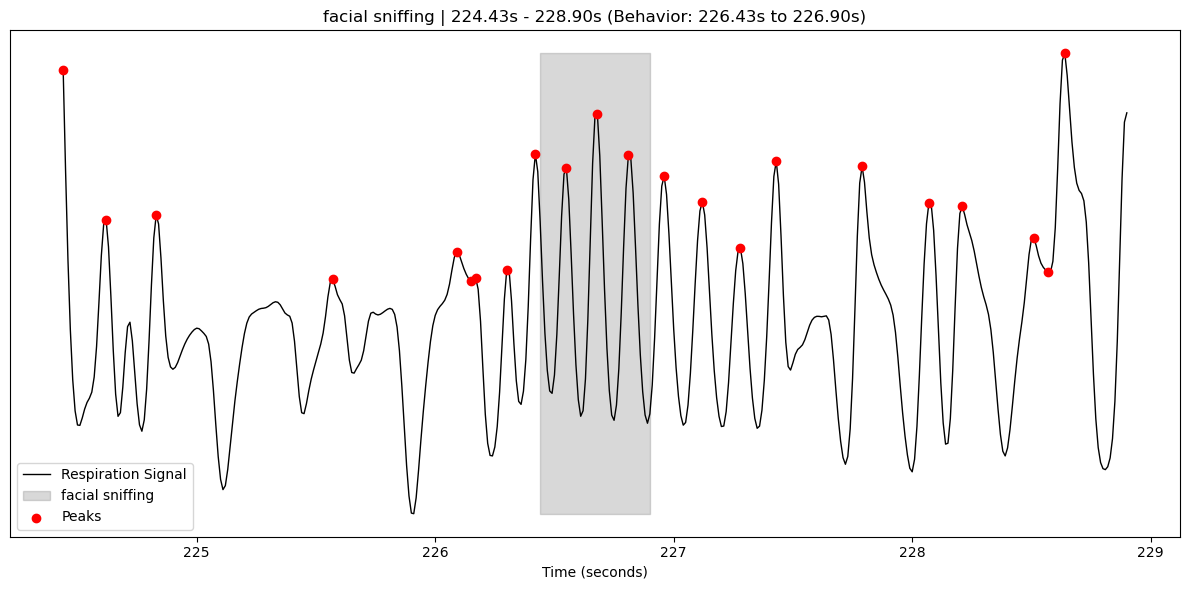

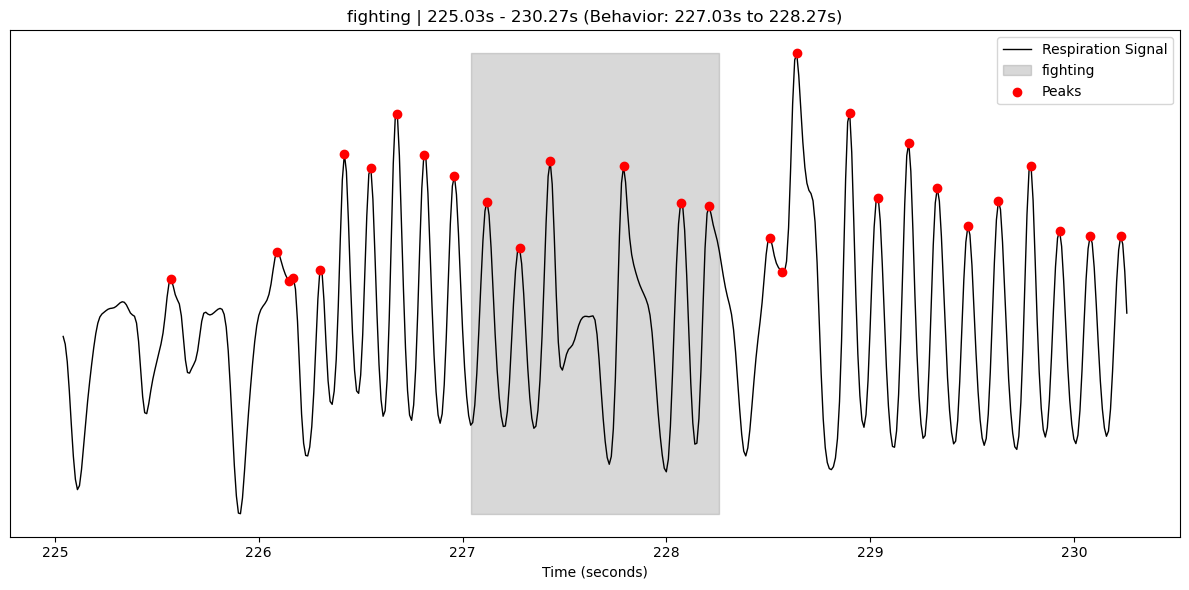

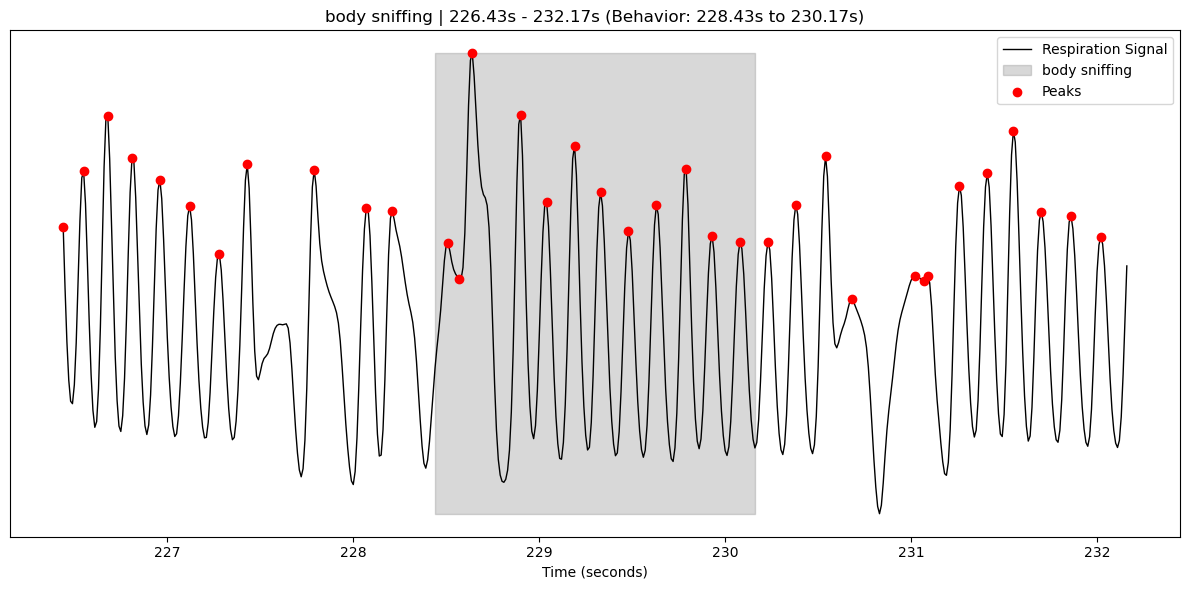

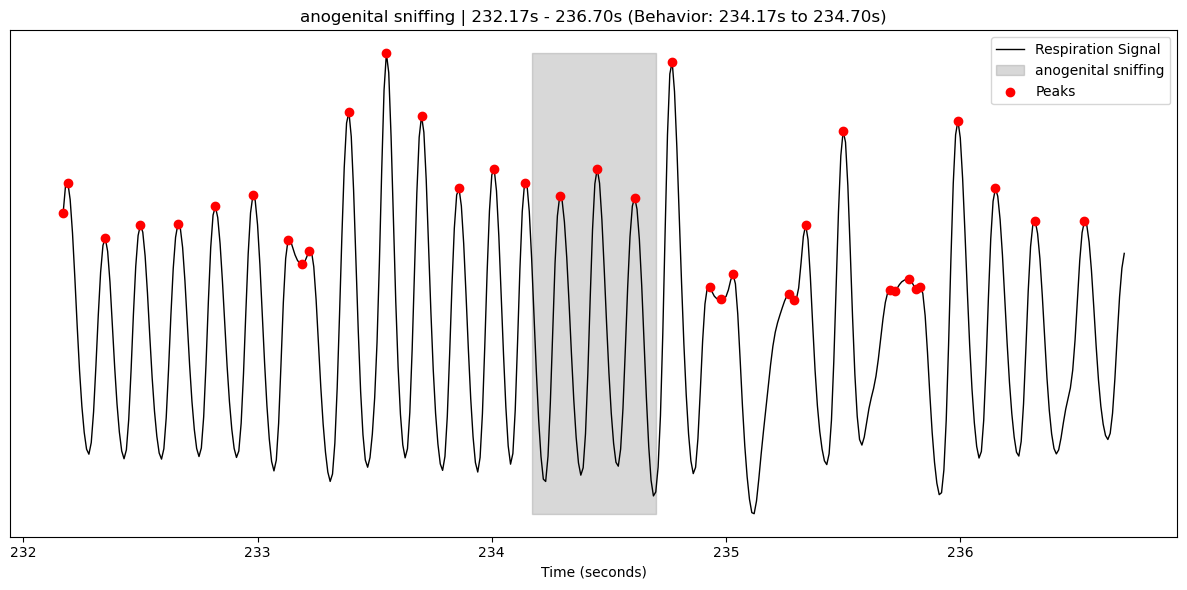

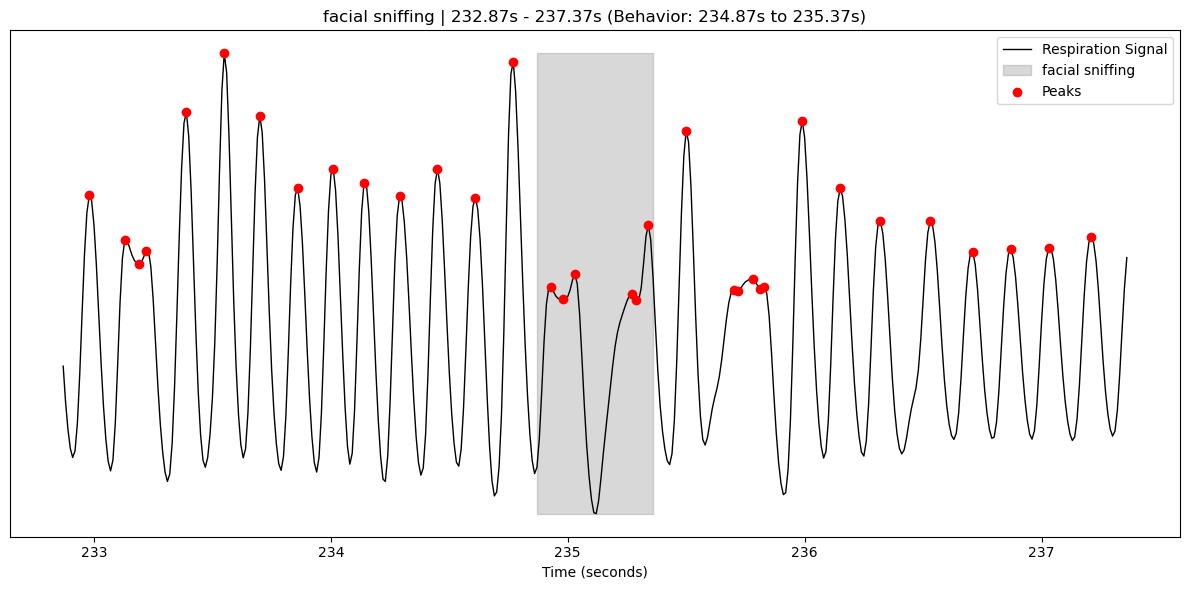

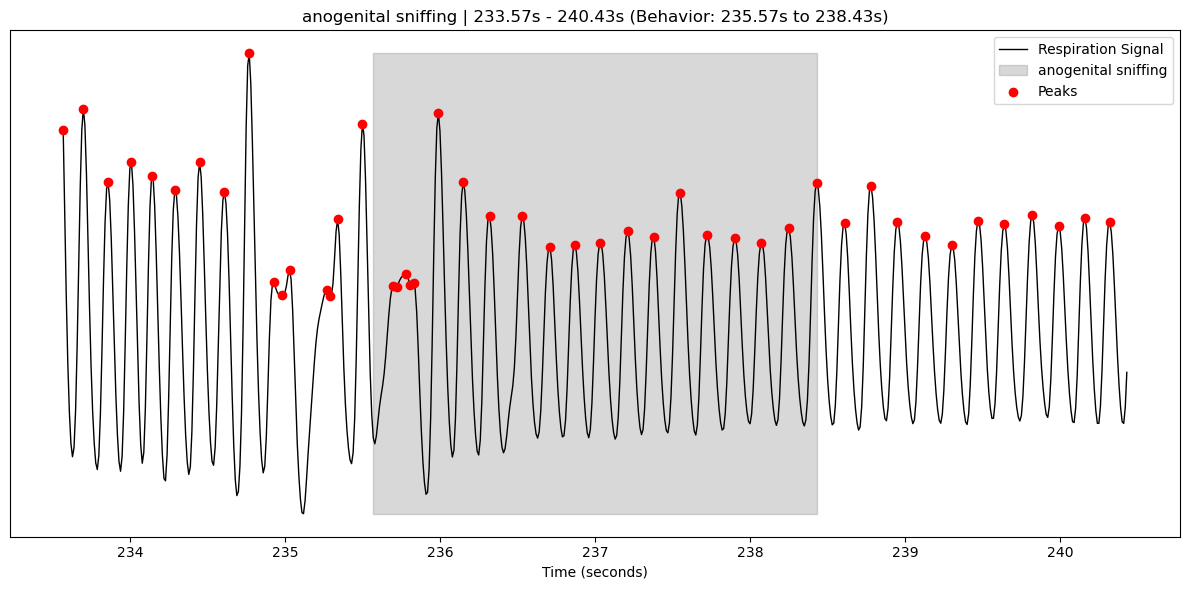

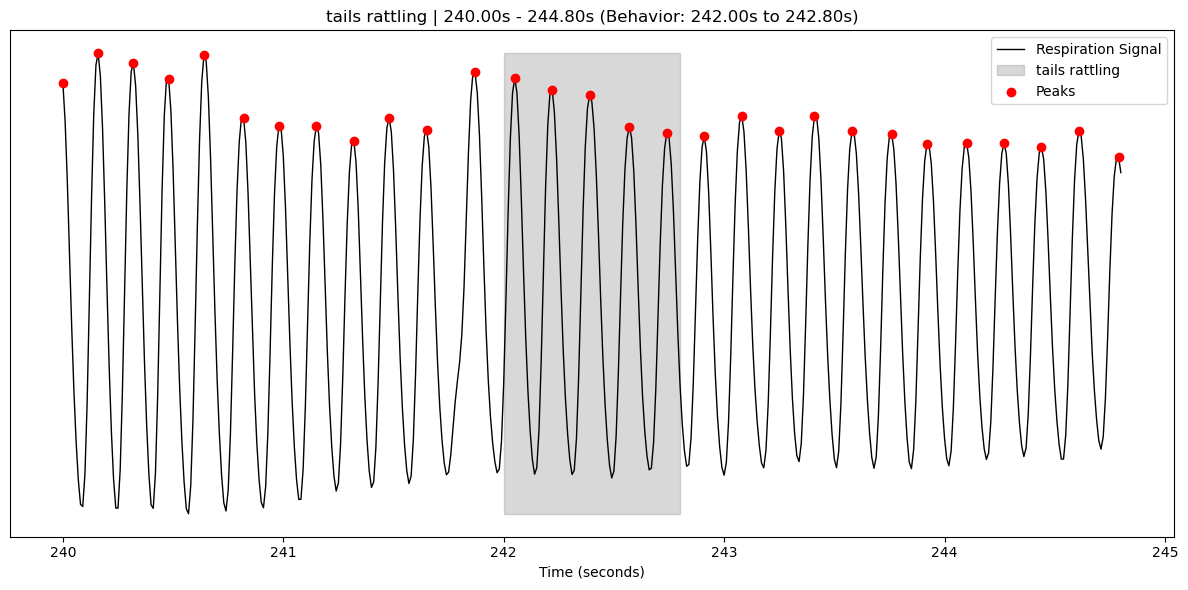

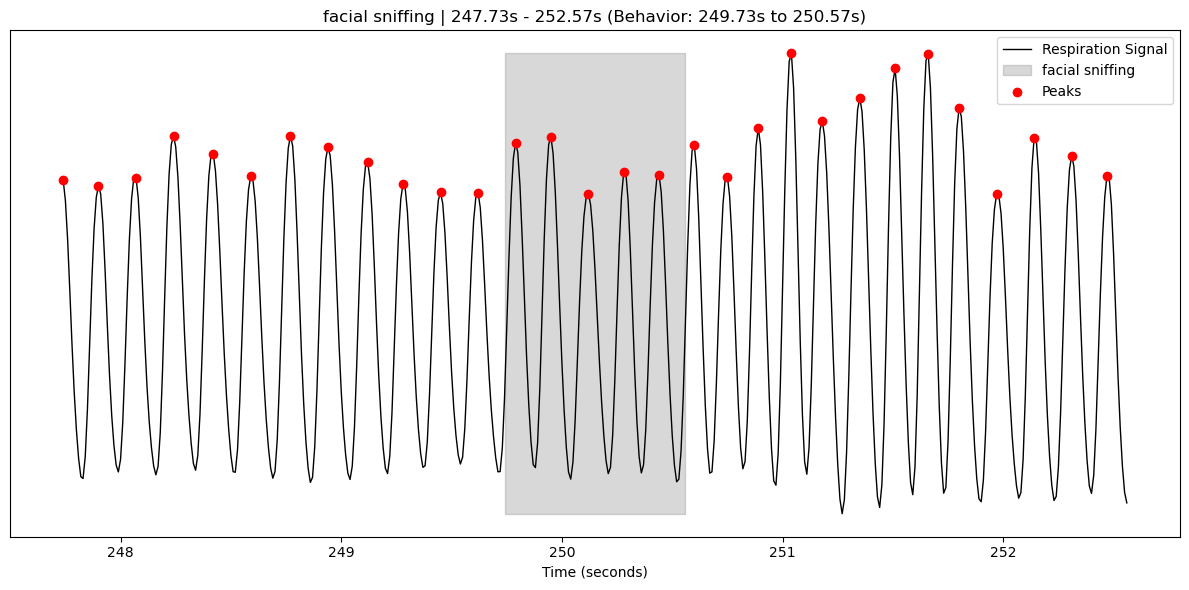

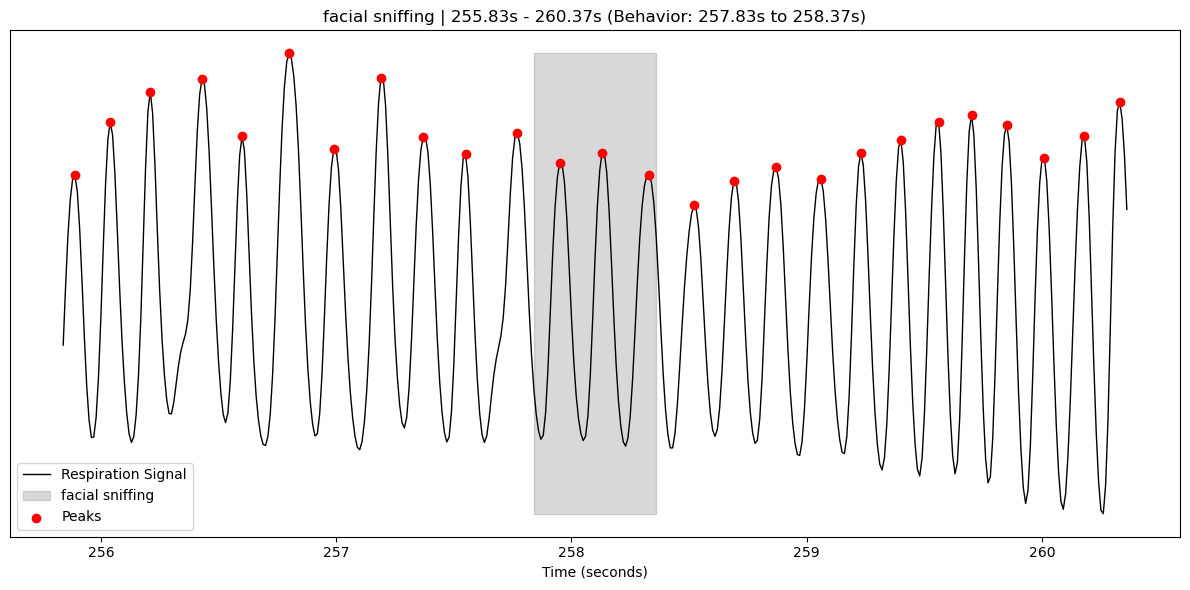

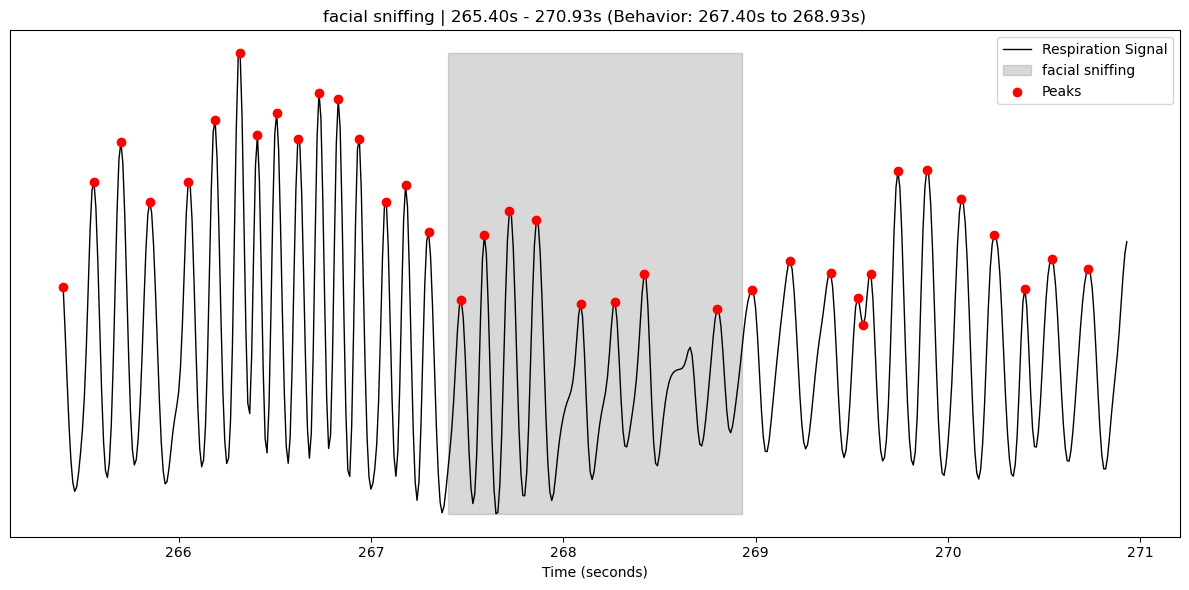

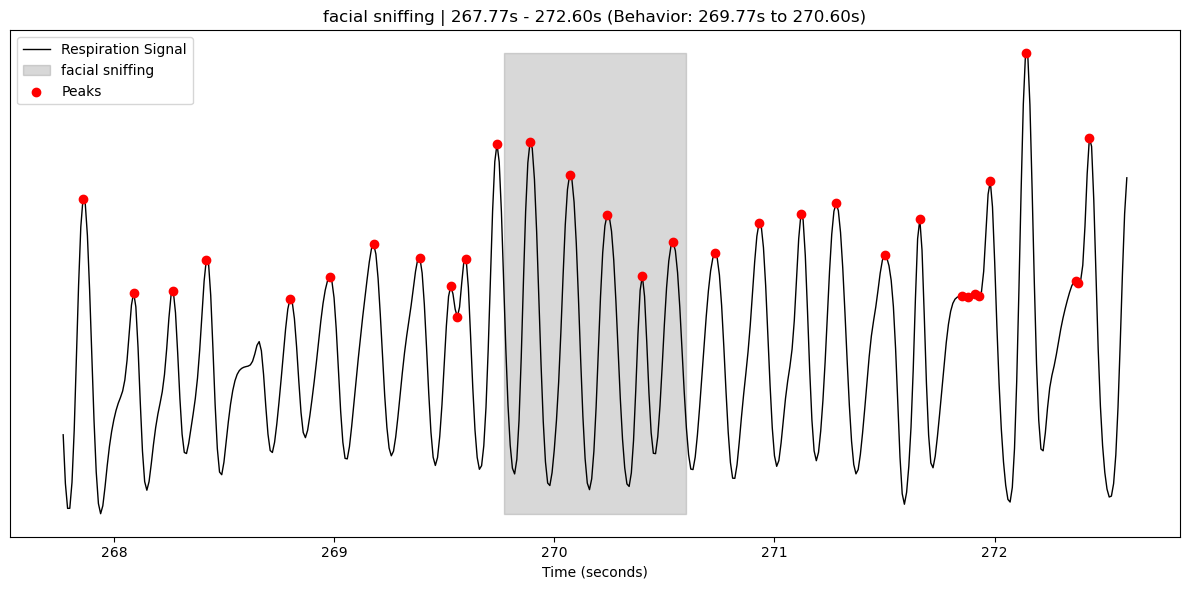

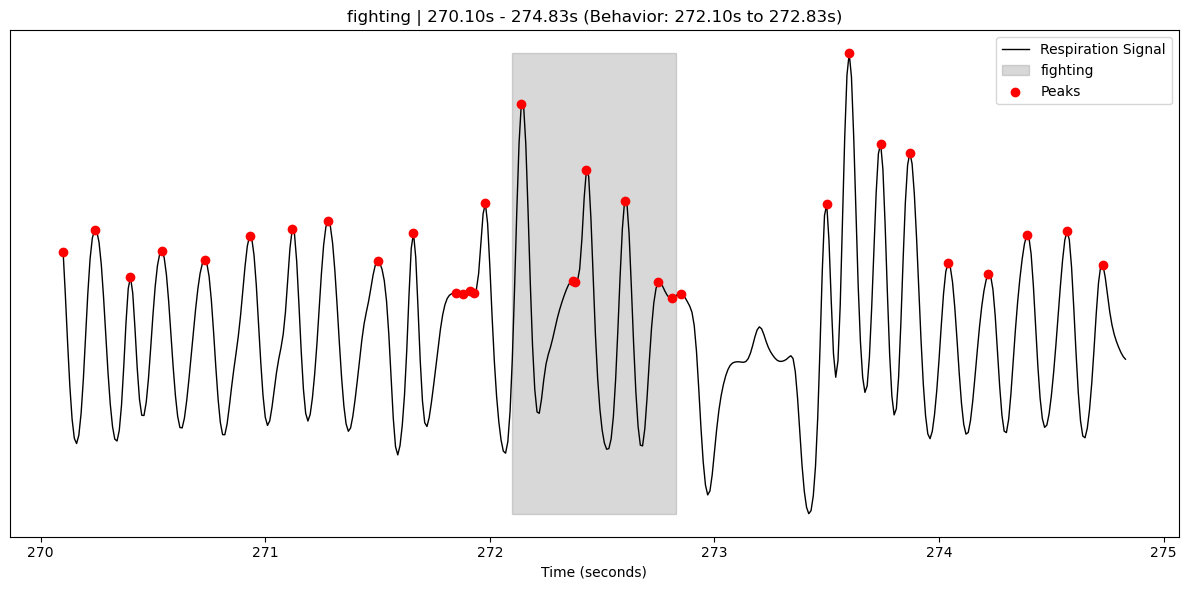

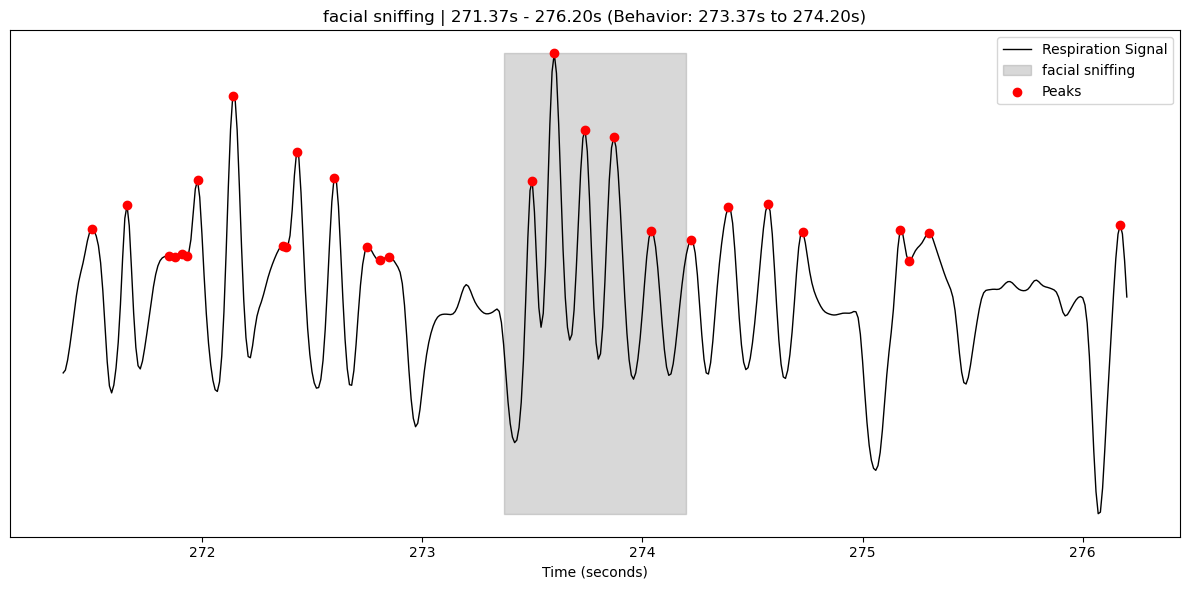

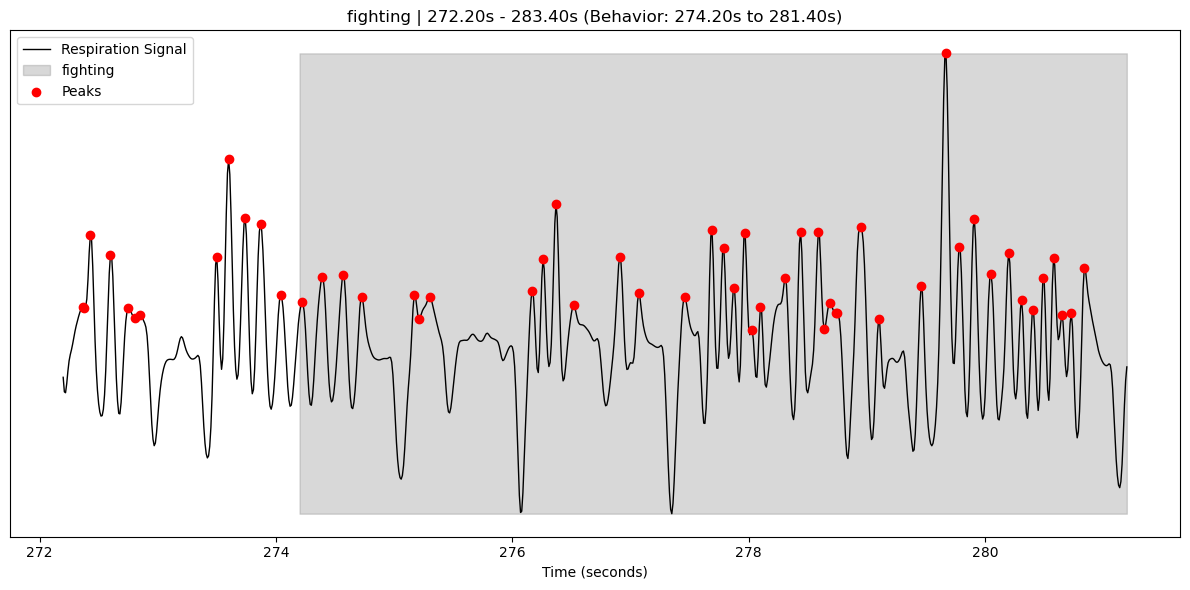

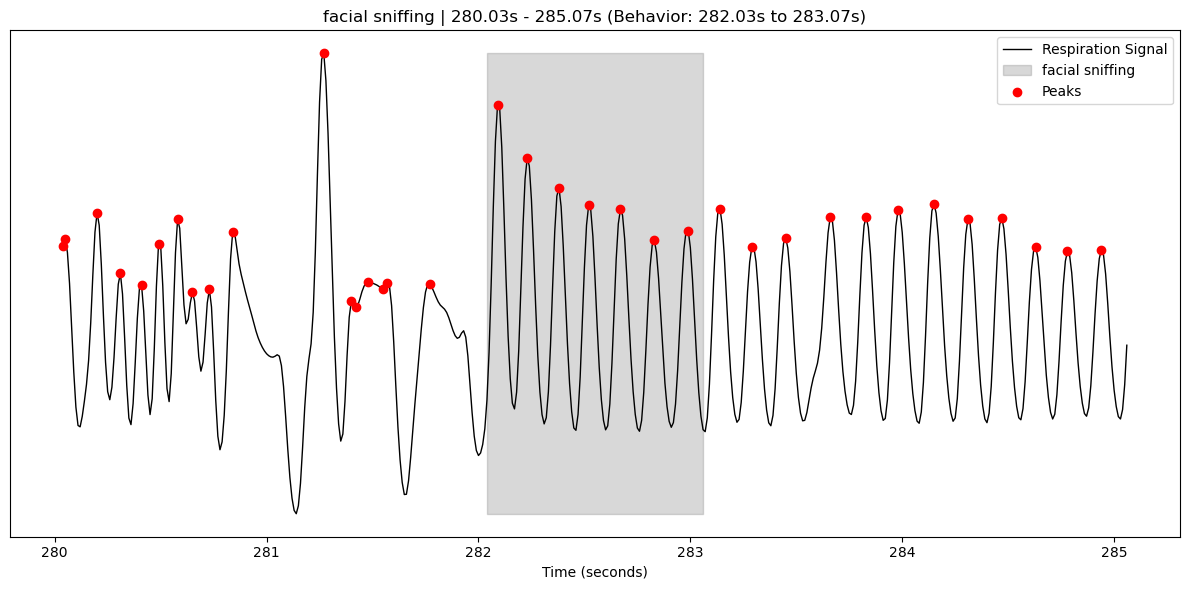

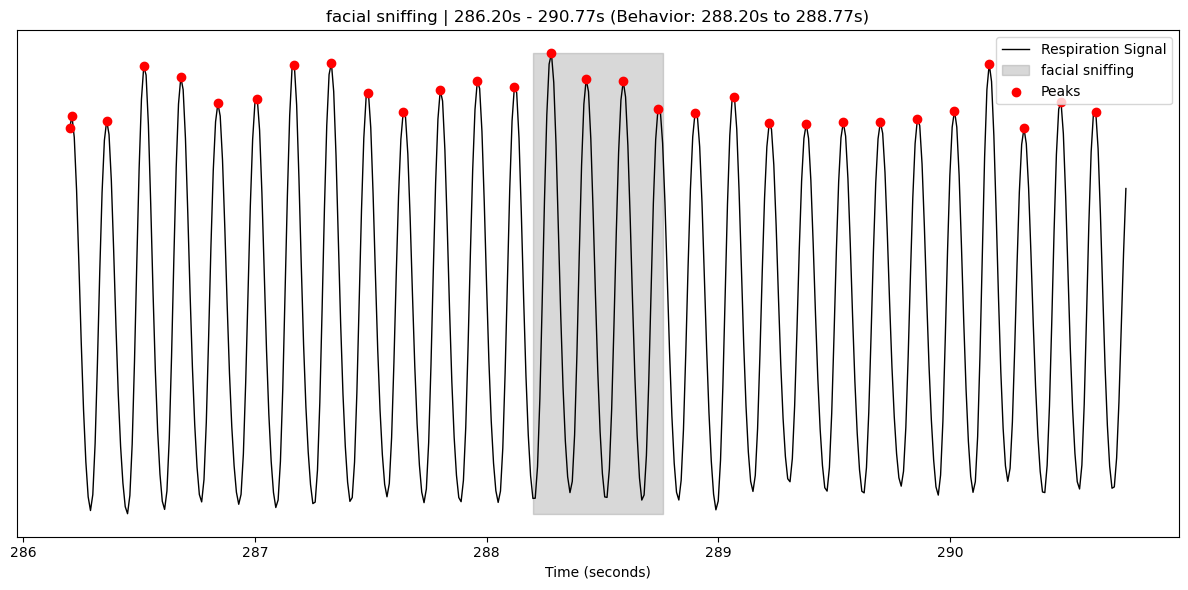

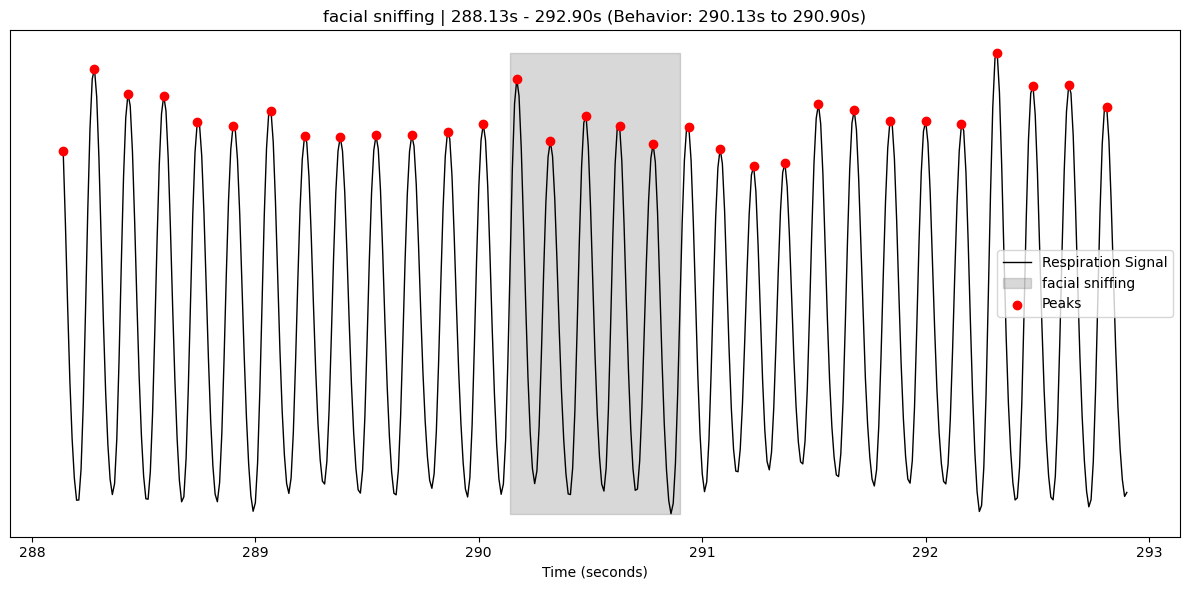

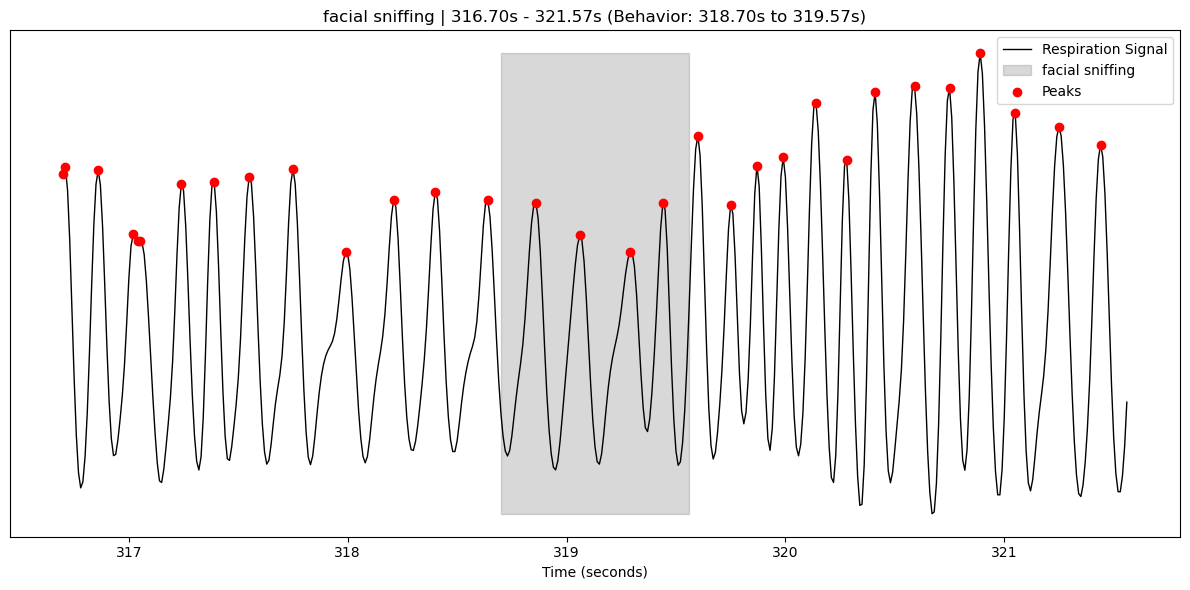

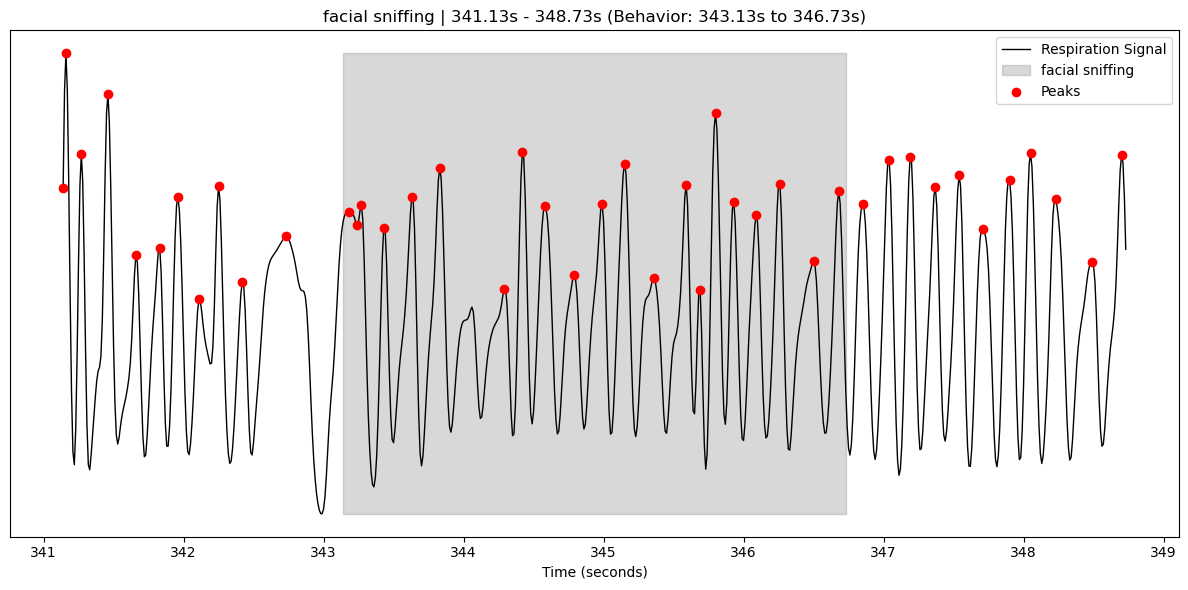

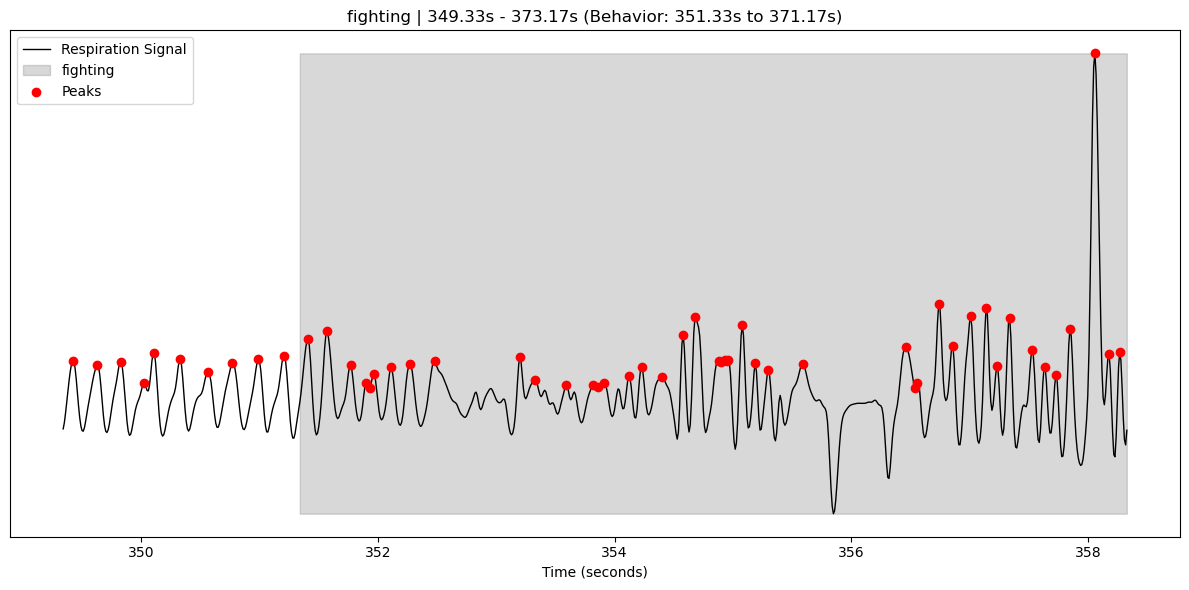

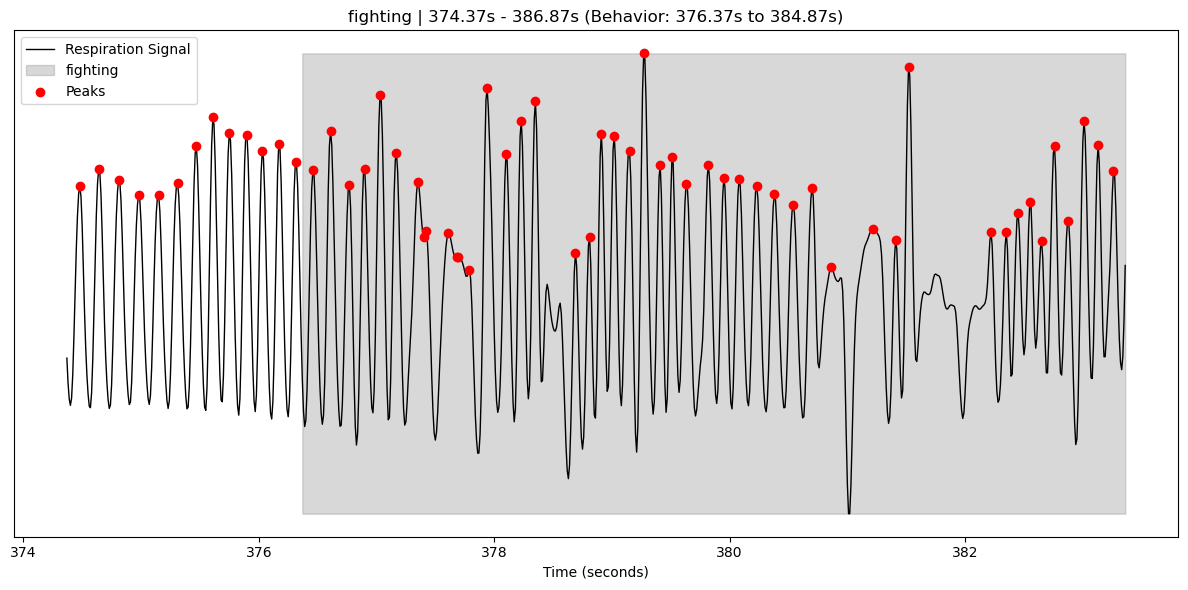

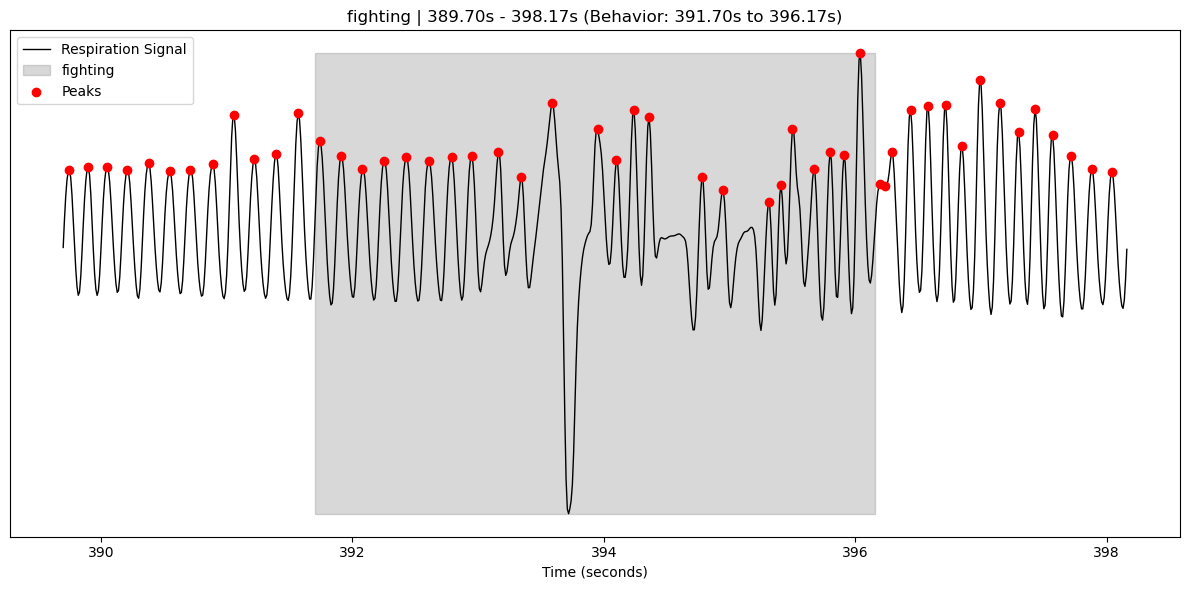

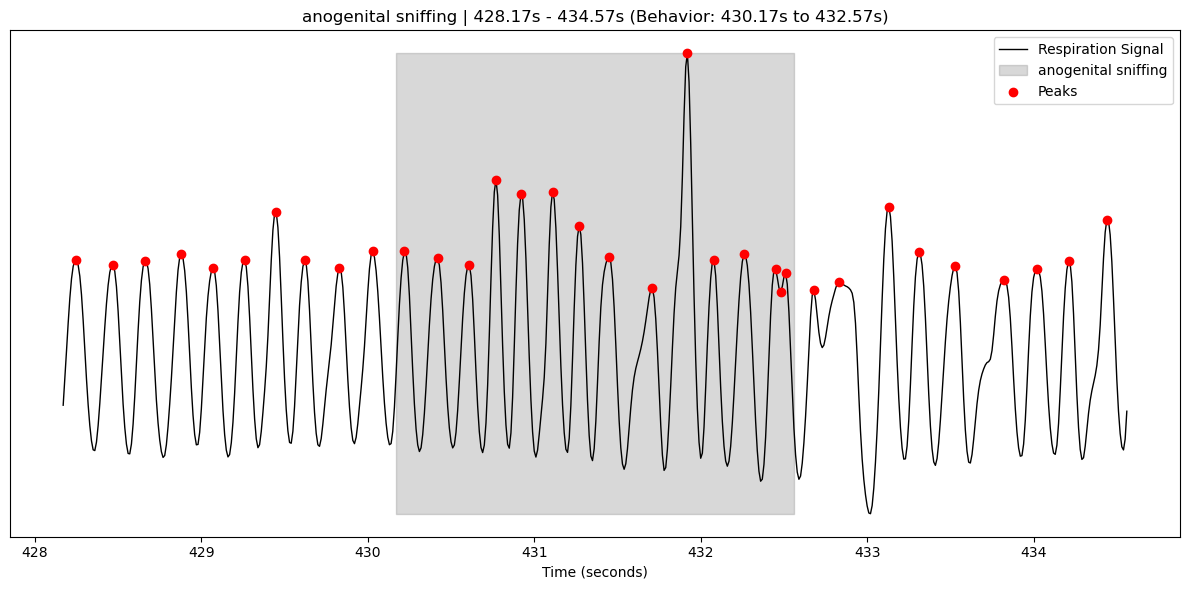

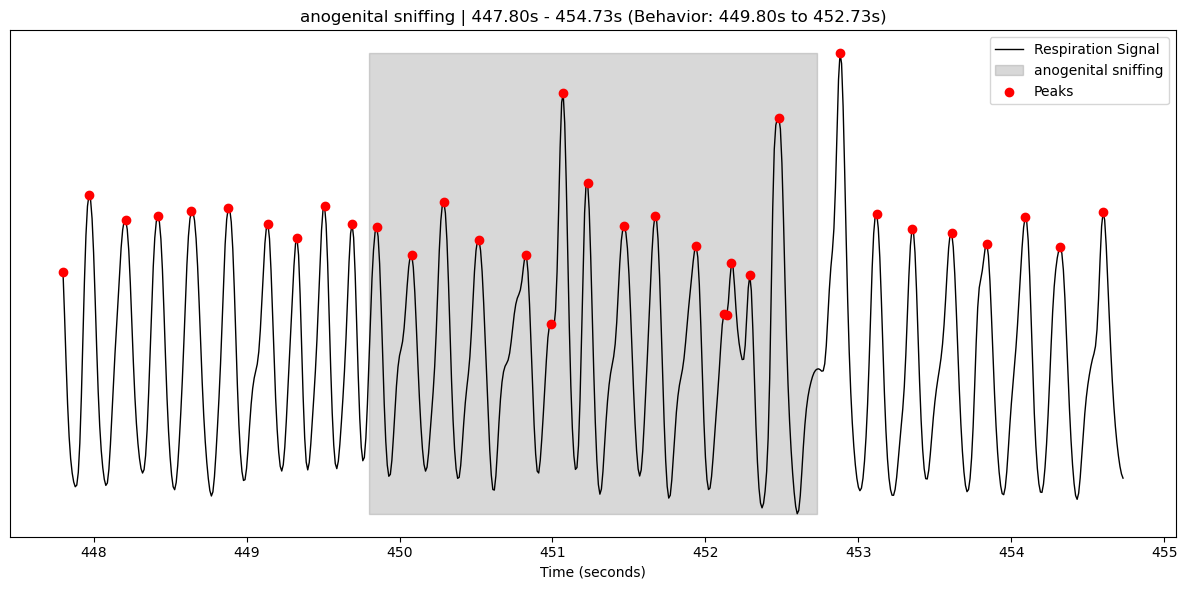

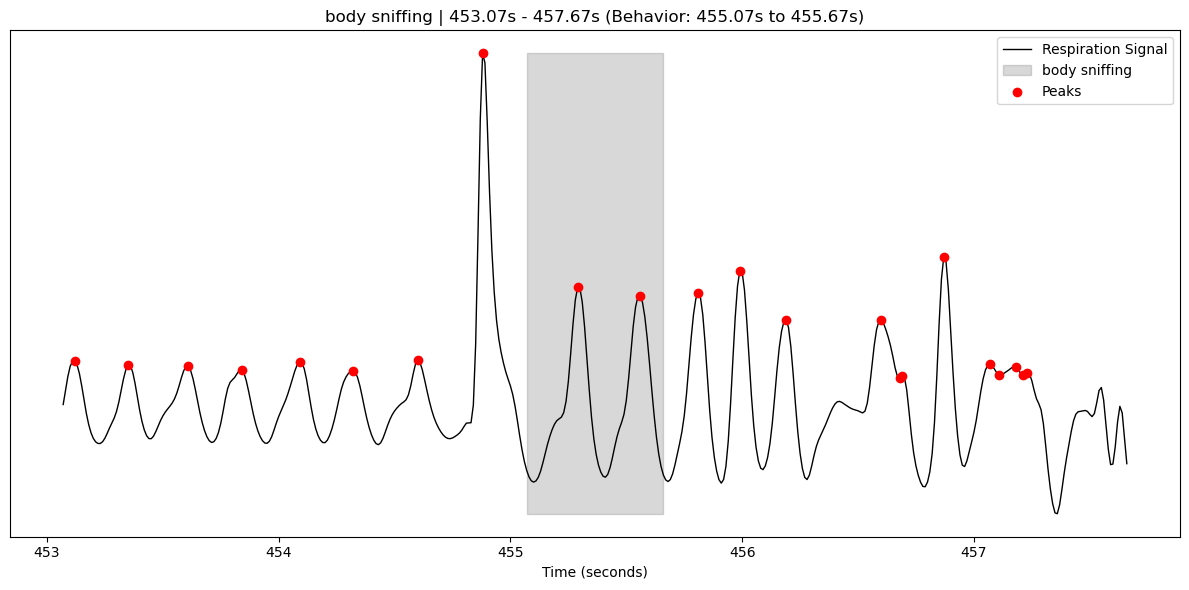

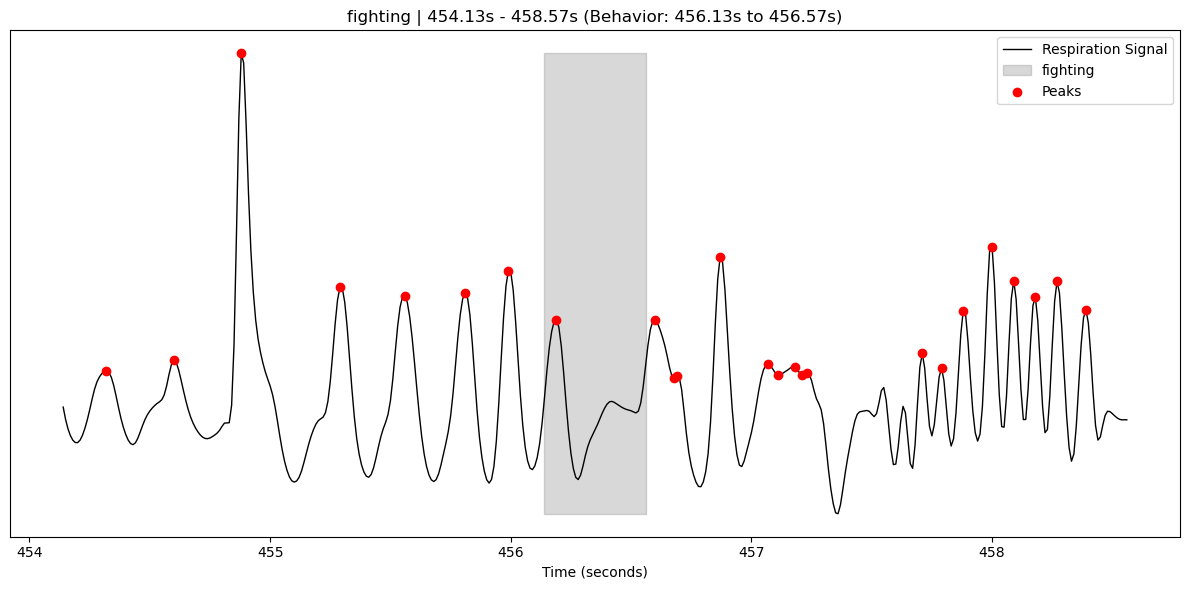

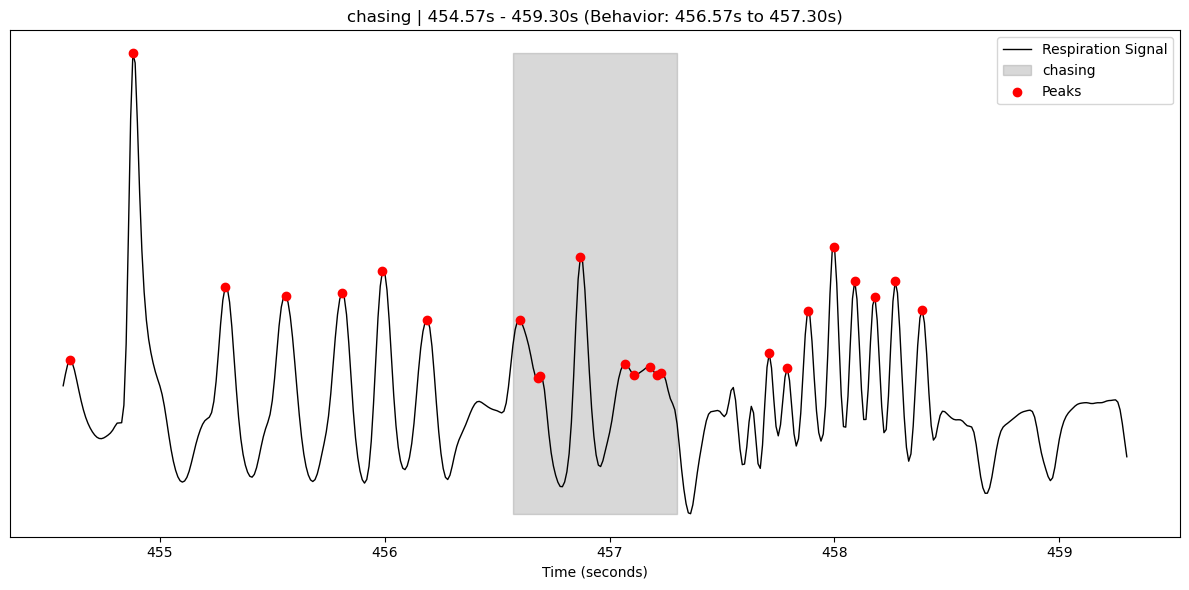

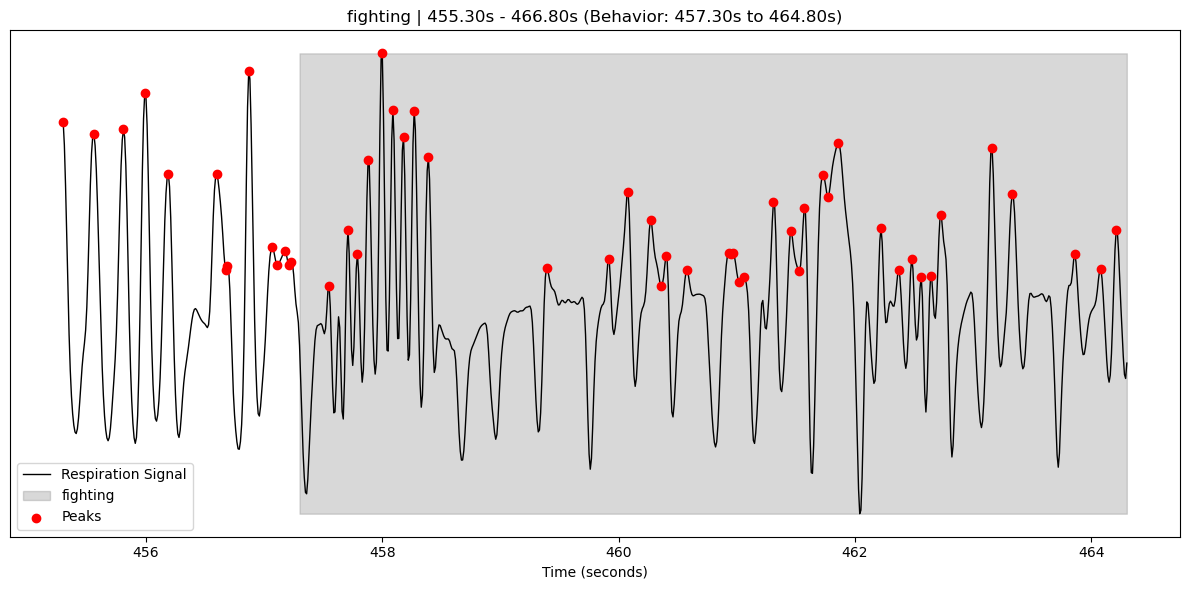

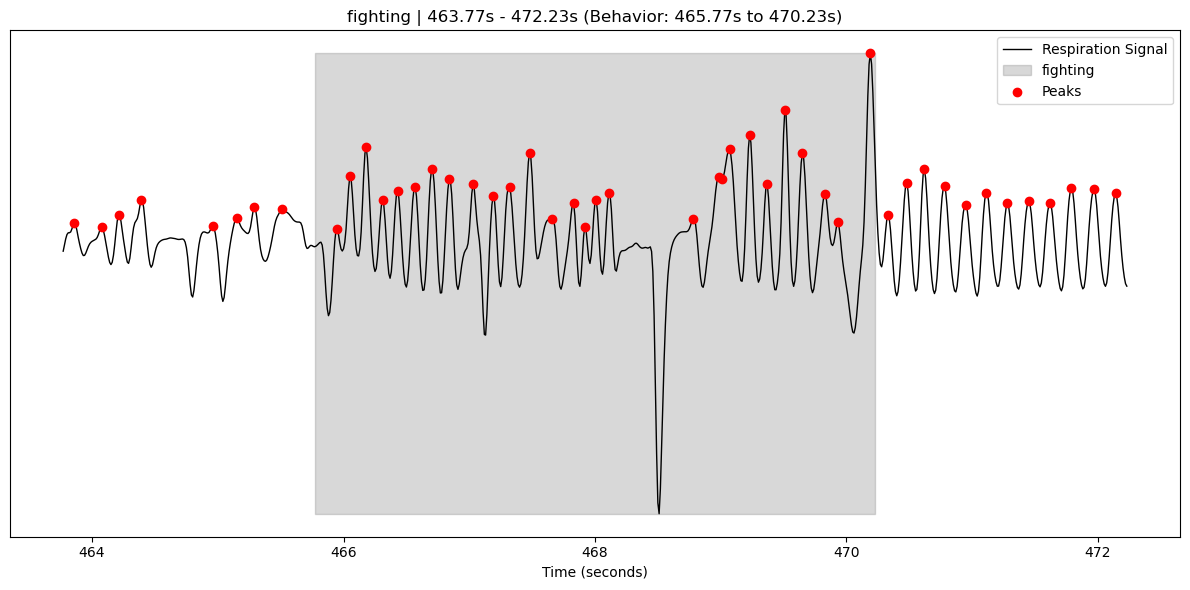

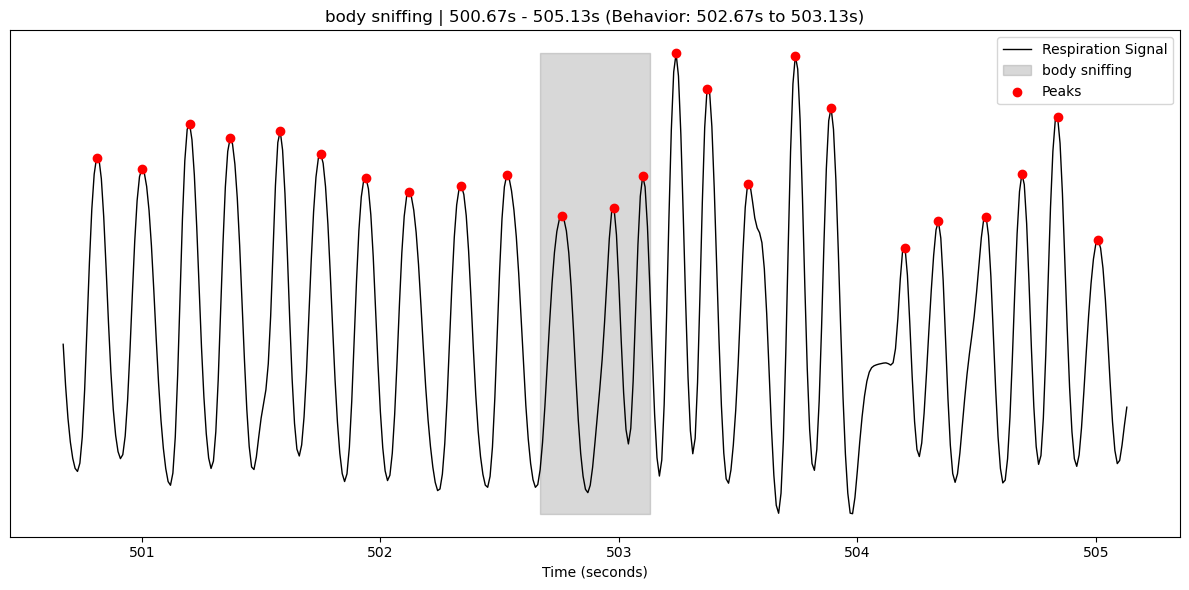

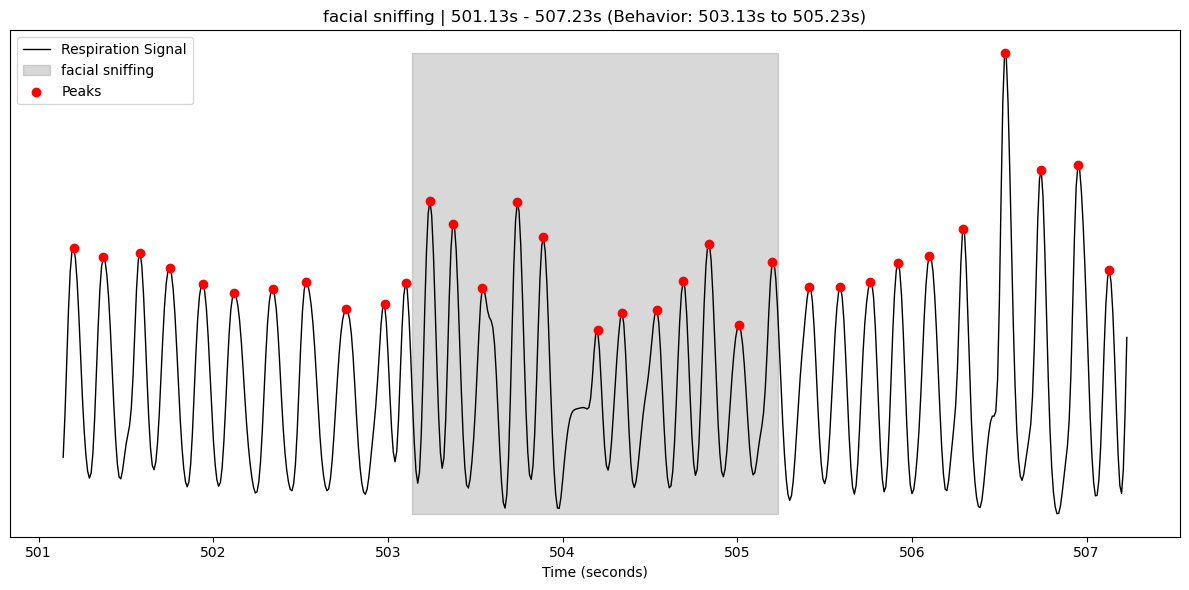

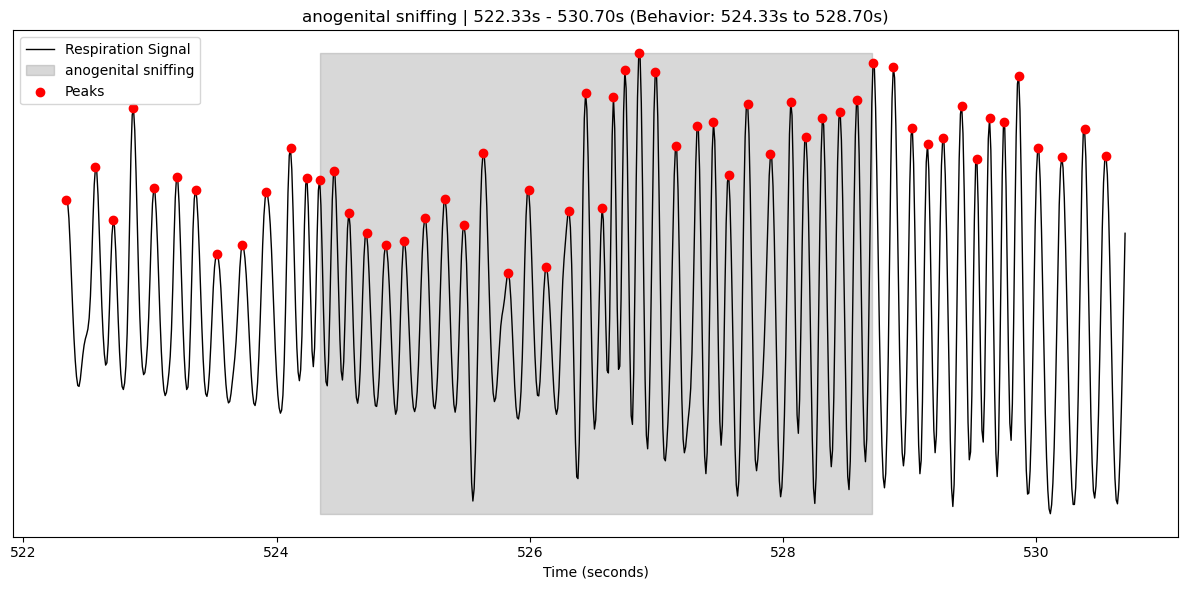

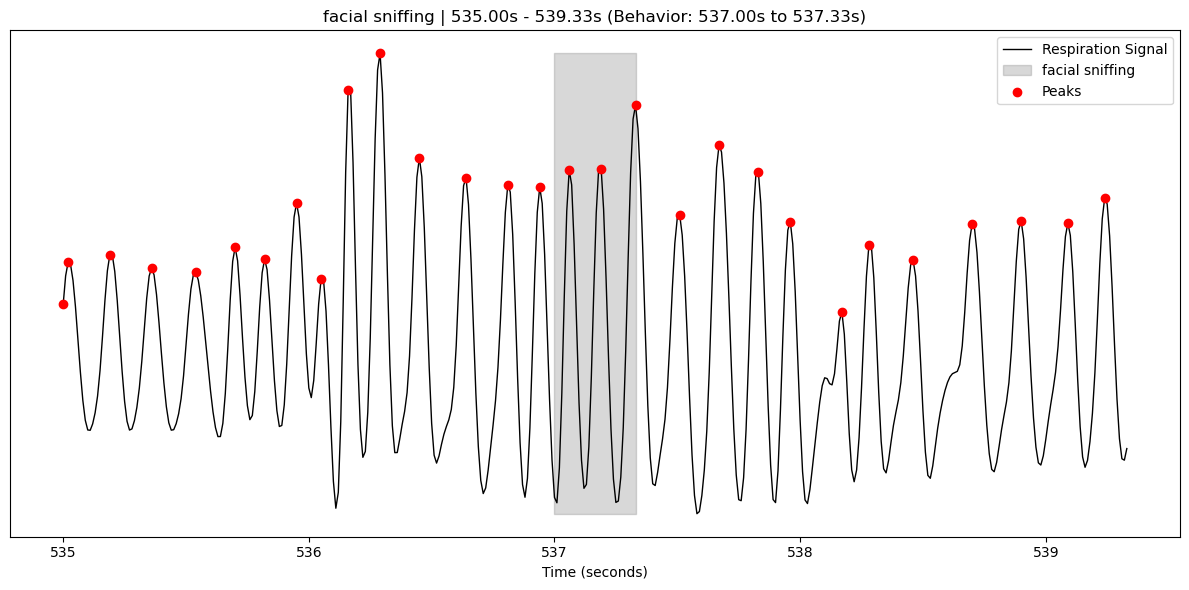

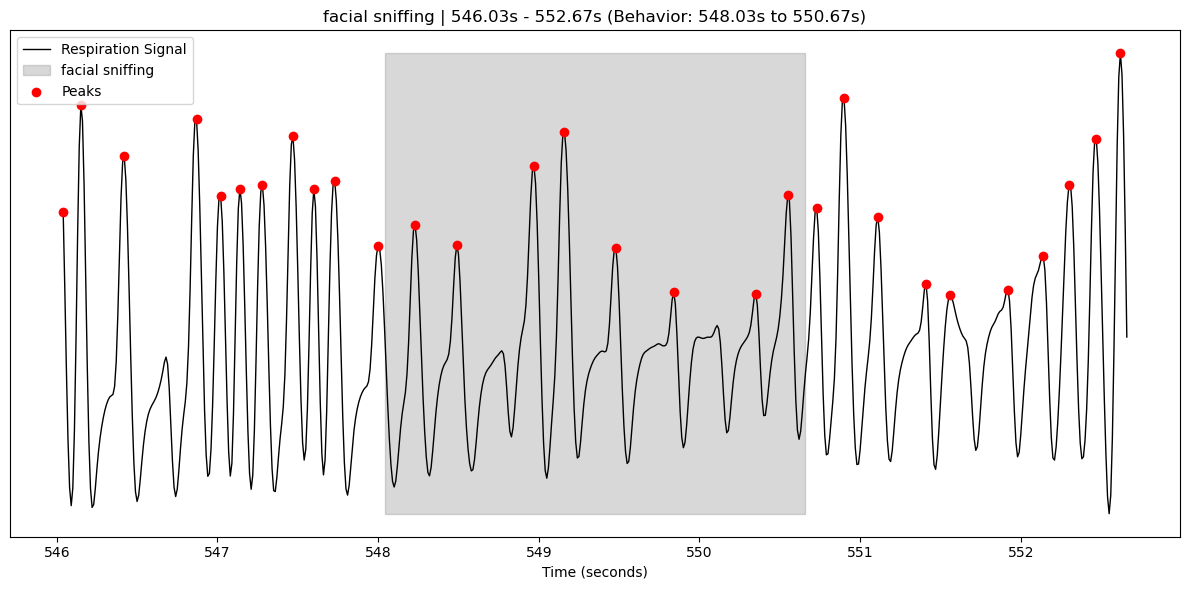

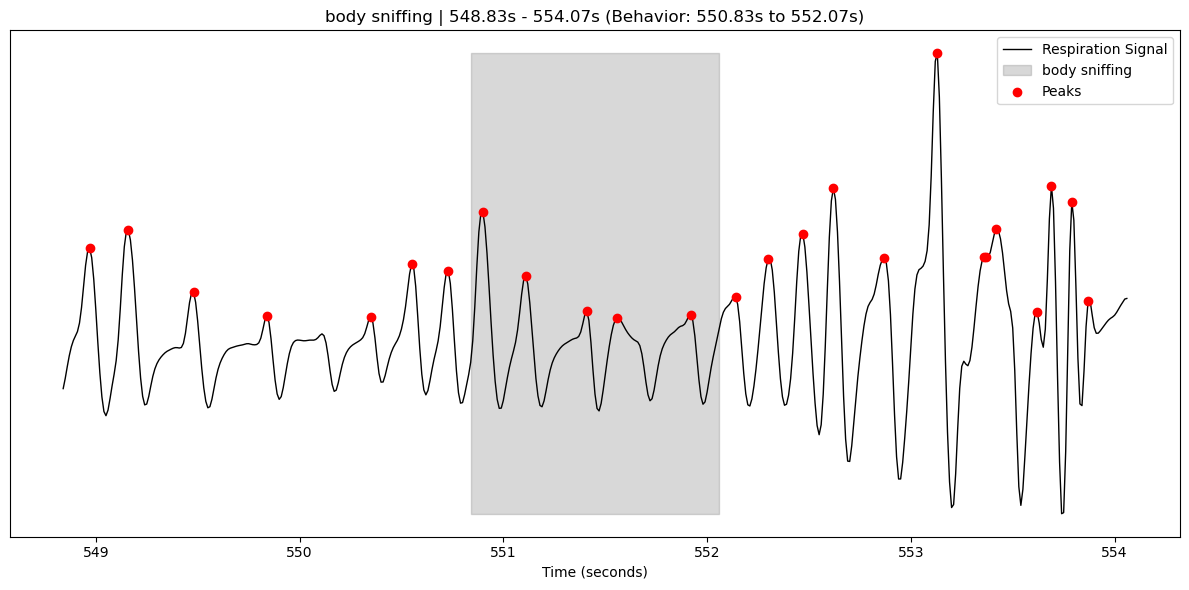

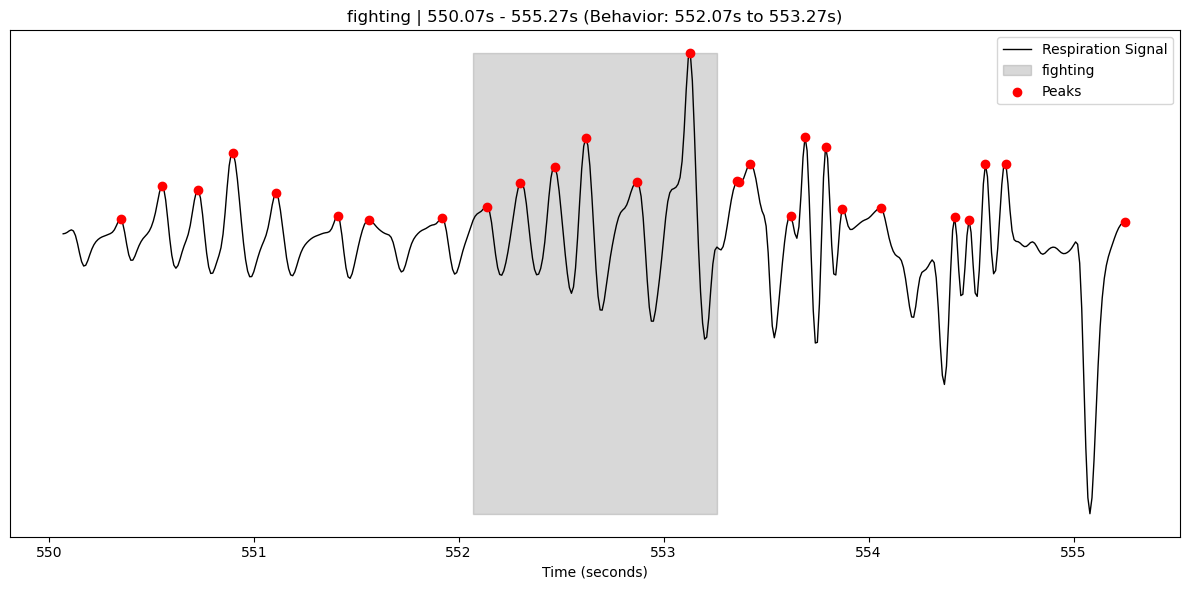

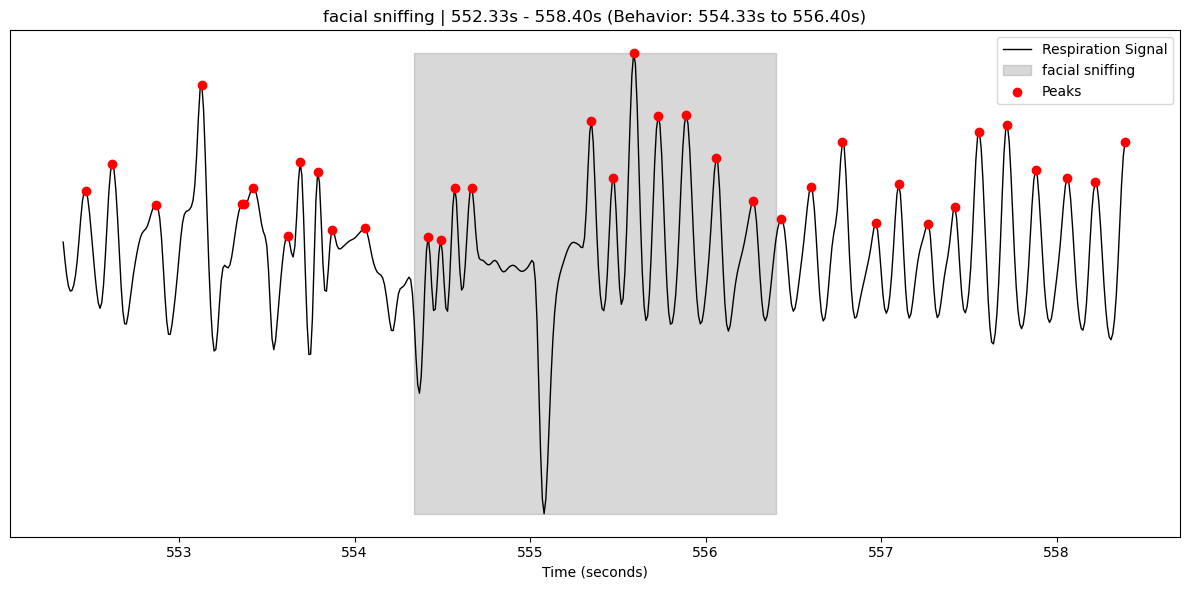

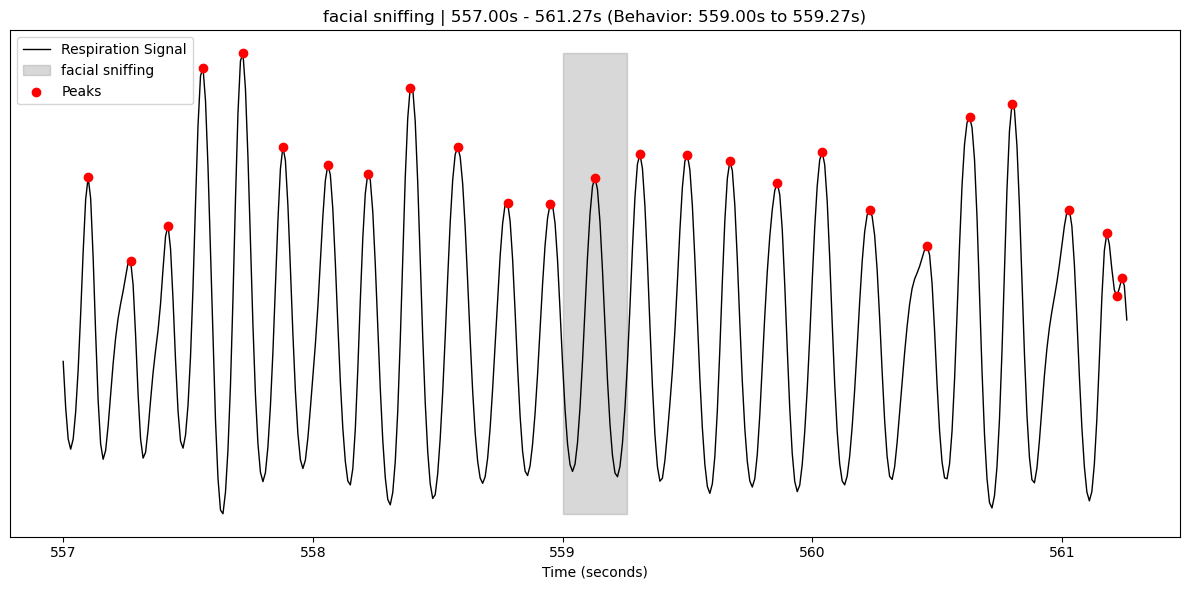

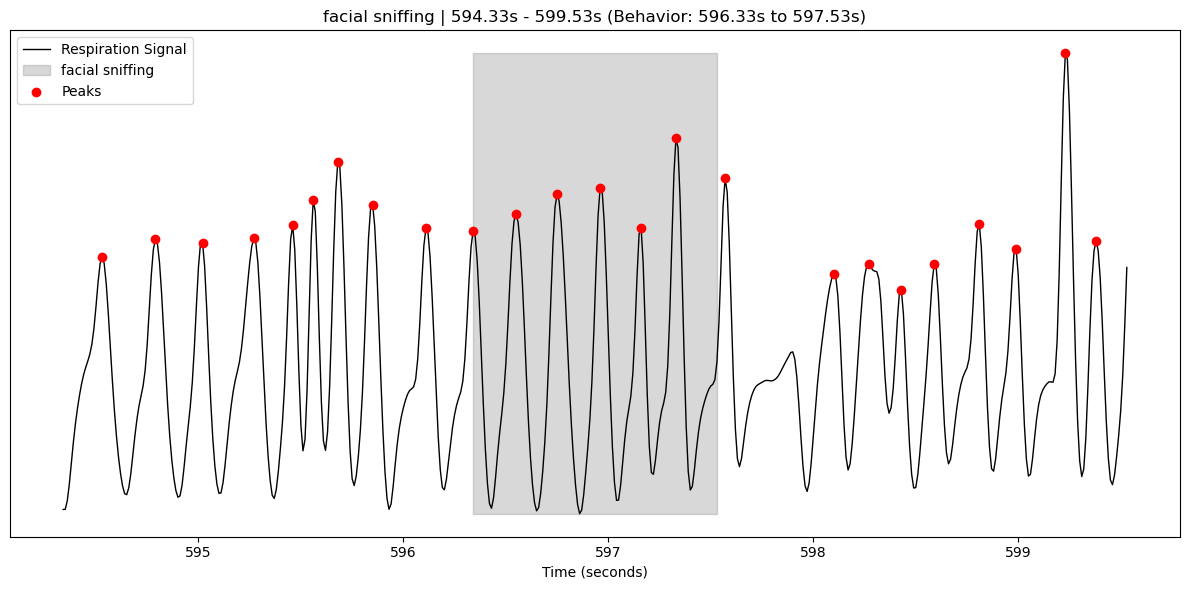

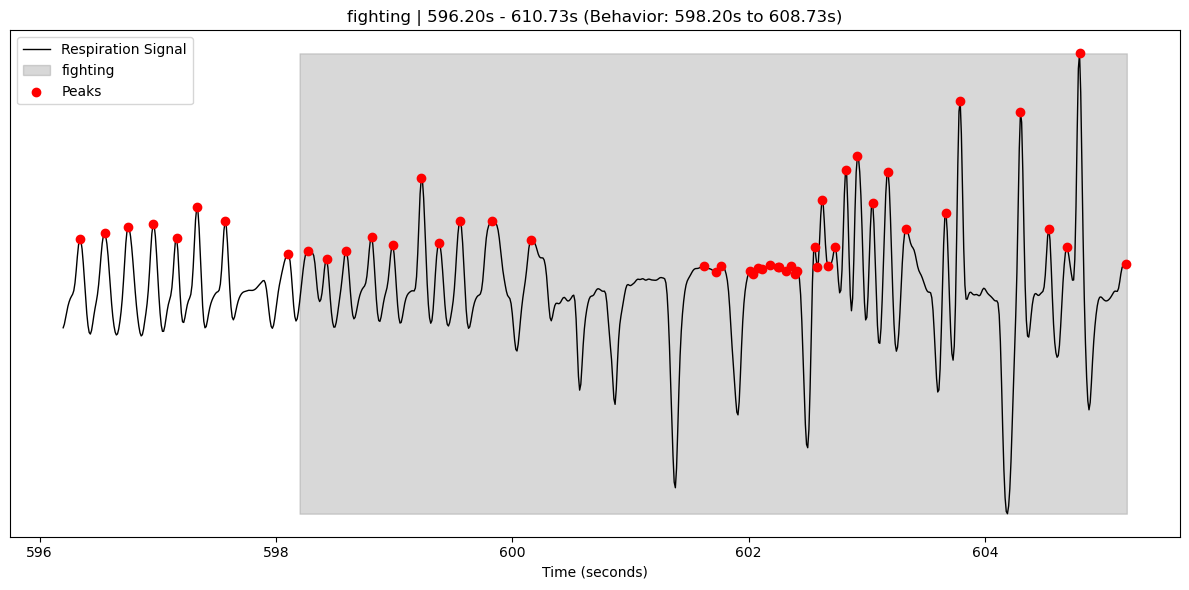

In [12]:
RI2_focal_subj_3_6_kit.plot_each_behavior_event(show_peaks=True, pre_behavior=2, max_behavior_duration=7, post_behavior=2, exclude="Posturing")

In [ ]:
print("work")

work
